In [1]:
import os ; os.chdir('/home/sebastiaan/phd/repositories/immune_response_detection')

import pandas as pd
import numpy as np
import networkx as nx
import igraph as ig

import leidenalg as la
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import igraph as ig
import seaborn as sns
import faiss
from matplotlib import cm
from matplotlib.colors import Normalize

from clustcrdist.repertoire import Repertoire
from clustcrdist.neighbors import neighbor_analysis
from clustcrdist.encoding import TCRDistEncoder
from clustcrdist.constants.datasets import load_vdjdb
from clustcrdist.constants.modules.tcrdist.tcr_distances import TcrDistCalculator

# Setting up the plot styles
plt.style.use(['seaborn-v0_8-white', 'seaborn-v0_8-paper'])
plt.rc('font', family='serif')
sns.set_palette('Set1')
sns.set_context('paper', font_scale=1.3)    # single-column figure

Matplotlib is building the font cache; this may take a moment.


## Parsing function

In [2]:
def parse_data(fraction='cd4', remove_mait=False):
    
    data = pd.read_table(f'./data/{fraction}_data.tsv')
    data['va'] = data['va'] + '*01'
    data['ja'] = data['ja'] + '*01'
    data['vb'] = data['vb'] + '*01'
    data['jb'] = data['jb'] + '*01'

    formatter = Repertoire(data)
    data = formatter.filter_and_format_paired(
        cdr3nt_a_col = 'alpha_nuc_seq',
        cdr3nt_b_col = 'beta_nuc_seq',
    )

    clonecols = ['va', 'ja', 'cdr3a', 'cdr3a_nucseq', 'vb', 'jb', 'cdr3b', 'cdr3b_nucseq']
    data = data.drop_duplicates(subset=clonecols + ['timepoint'])
    data['is_mait'] = ((data['va'] == 'TRAV1-2*01') & (data['ja'].isin(['TRAJ33*01', 'TRAJ20*01', 'TRAJ12*01'])))
    if remove_mait:
        data = data[~data['is_mait']]
    data = data.reset_index(drop=True)

    pre = data[data['timepoint'] == f'{fraction}_pre'].reset_index(drop=True)
    acute = data[data['timepoint'] == f'{fraction}_acute'].reset_index(drop=True)
    conv = data[data['timepoint'] == f'{fraction}_conv'].reset_index(drop=True)

    return data, pre, acute, conv

## VDJdb

In [3]:
from clustcrdist.constants.datasets import load_vdjdb

print(load_vdjdb(chain='B').shape)
print(load_vdjdb(chain='A').shape)

(26993, 5)
(14680, 5)


In [4]:
def has_gene(allele):
    donor_hla = ['HLA-A*02','HLA-A*03','HLA-B*07','HLA-B*08','HLA-C*07']
    return any([True if i in allele else False for i in donor_hla])

tenx_study = 'https://www.10xgenomics.com/resources/application-notes/a-new-way-of-exploring-immunity-linking-highly-multiplexed-antigen-recognition-to-immune-repertoire-and-phenotype/#'

cols = ['cdr3a', 'va', 'ja', 'cdr3b', 'vb', 'db', 'jb', 
'species', 'mhc.a','mhc.b', 'mhc.class', 'antigen.epitope', 'antigen.gene', 'antigen.species', 'reference.id', 
'meta.study.id', 'meta.cell.subset','meta.tissue', 'meta.donor.MHC','vdjdb.score']

vdjdb = pd.read_table('./clustcrdist/constants/data/vdjdb/vdjdb_full.txt')
vdjdb_paired = vdjdb.dropna(subset=['cdr3.alpha', 'v.alpha', 'j.alpha', 'cdr3.beta', 'v.beta','j.beta'])

vdjdb_paired = vdjdb_paired[vdjdb_paired['reference.id']!=tenx_study]
vdjdb_paired = vdjdb_paired[vdjdb_paired.species == 'HomoSapiens']

col_rename = {
    'cdr3.alpha':'cdr3a',
    'v.alpha':'va',
    'j.alpha':'ja',
    'cdr3.beta':'cdr3b',
    'v.beta':'vb',
    'd.beta':'db',
    'j.beta':'jb',
}

vdjdb_paired = vdjdb_paired.rename(columns=col_rename)
vdjdb_paired = vdjdb_paired[cols]
vdjdb_paired = vdjdb_paired.drop_duplicates()

vdjdb_paired = vdjdb_paired[vdjdb_paired['mhc.a'].apply(has_gene)]
vdjdb_paired = vdjdb_paired.reset_index(drop=True)

/tmp/ipykernel_436488/2028066258.py:11: DtypeWarning: Columns (20,29,30) have mixed types. Specify dtype option on import or set low_memory=False.
  vdjdb = pd.read_table('./clustcrdist/constants/data/vdjdb/vdjdb_full.txt')


## Functions

In [5]:
def convert_range_search_output(lims, D, I, offset=0):
    '''
    Convert the output of a range search to a list of tuples.
    '''
    # Calculate the number of queries
    num_queries = len(lims) - 1
    # Vectorize the construction of result pairs
    result_indices = []
    result_distances = []
    for i in range(num_queries):
        start = lims[i]
        end = lims[i + 1]
        query_indices = np.full(end - start, i)
        neighbor_indices = I[start:end] + offset
        distances = D[start:end]
        result_indices.extend(zip(query_indices, neighbor_indices))
        result_distances.extend(distances)
    result = list(zip(result_indices, result_distances))
    return result

def vdjdb_annotation_network(sne, vdjdb_paired, fig, ax, legend=False, cutoff=None, annotate=False, plot_cbar=False):

    col_remap = {
        'junction_aa_alpha':'cdr3a', 
        'v_call_alpha':'va', 
        'j_call_alpha':'ja', 
        'junction_aa_beta':'cdr3b',
        'v_call_beta':'vb',
        'j_call_beta':'jb'
    }

    if list(col_remap.keys())[0] in sne.columns:
        sne = sne.rename(columns=col_remap)

    encoder = TCRDistEncoder(aa_dim=16, chain='AB').fit()
    qvecs = encoder.transform(sne)
    rvecs = encoder.transform(vdjdb_paired)

    index = faiss.IndexFlatL2(qvecs.shape[1])
    index.add(rvecs)

    lims, D, I = index.range_search(qvecs, thresh=90)
    edges = convert_range_search_output(lims, D, I)

    edges = [(str(i[0][0]) + '_SNE', str(i[0][1]) + '_VDJDB', i[1]) for i in edges]

    species_color = {
        'InfluenzaA':'#ec7063',
        'SARS-CoV-2':'#85c1e9',
        'CMV':'#7dcea0',
        'HCV':'#961cea',
        'HomoSapiens':'#fcb5eb',
        'EBV':'#0b5345',
        'YFV':'#f9e79f',
        'Influenza B':'#943126',
        'synthetic':'#b2babb',
        'HCoV-HKU1':'#b2babb',
        'HSV-2':'#b2babb',
        'HIV-1':'#b2babb',
        'HTLV-1':'#b2babb',
        'MCPyV':'#b2babb',
        'SaccharomycesCerevisiae':'#b2babb'
    }

    nodes = []
    for i in edges:
        nodes += i[:2]
    nodes = list(set(nodes))

    G = nx.Graph()
    G.add_nodes_from(nodes)
    G.add_weighted_edges_from(edges)

    Gi = ig.Graph.from_networkx(G)

    layout = Gi.layout("graphopt", niter=1000)

    # fig, ax = plt.subplots(dpi=150, figsize=(5,5))

    visual_style = {'edge_width': 0.5,}
    ig.plot(Gi,
            layout=layout,
            **visual_style,
            target=ax)

    x = [i[0] for i in layout]
    y = [i[1] for i in layout]

    nodenames = [i['_nx_name'] for i in Gi.vs]

    annotated = [int(i.split('_')[0]) for i in nodenames if 'SNE' in i]
    annotated = sne.loc[annotated]

    if annotate:

        # Sample evalue range based on the specified transformation
        evalue_min = (-np.log10(annotated.evalue)).min()
        evalue_max = (-np.log10(annotated.evalue)).max()

        # Normalize the range of evalues
        norm = Normalize(vmin=evalue_min, vmax=evalue_max)

        # Create a ScalarMappable to map the values to the viridis colormap
        viridis_cmap = cm.ScalarMappable(norm=norm, cmap='viridis')

    for n, i in enumerate(nodenames):
        if 'SNE' in i:
            if annotate:
                evalue = sne.loc[int(i.split('_')[0])]['evalue']
                if cutoff is not None:
                    if evalue < cutoff:
                        color = 'red'
                    else:
                        color = 'white'
                else:
                    color = viridis_cmap.to_rgba(-np.log10(evalue))
            else:
                color = 'white'
            ax.scatter(x[n], y[n], color=color,marker='s',s=15, edgecolors='k',linewidths=0.5, zorder=2,alpha=.75)
        else:
            species = vdjdb_paired.loc[int(i.split('_')[0])]['antigen.species']
            color = species_color[species]
            ax.scatter(x[n], y[n], color=color, s=10, edgecolors='k',linewidths=0.5, zorder=1)

    # Create a custom legend
    legend_color = {
        'InfluenzaA':'#ec7063',
        'SARS-CoV-2':'#85c1e9',
        'CMV':'#7dcea0',
        'HCV':'#961cea',
        'HomoSapiens':'#fcb5eb',
        'EBV':'#0b5345',
        'YFV':'#f9e79f',
        'Influenza B':'#943126',
        'other':'#b2babb',
    }

    legend_elements = [
        mlines.Line2D([], [], color=color, marker='o', markersize=8, markeredgewidth=0.5, markeredgecolor='black', linestyle='None', label=species)
        for species, color in legend_color.items()
    ]

    square = mlines.Line2D([], [], color='white', marker='s', markersize=12, markeredgewidth=0.5, markeredgecolor='black', linestyle='None', label='donor TCR')
    legend_elements += [square]
    if cutoff is not None:
        redsquare = mlines.Line2D([], [], color='red', marker='s', markersize=12, markeredgewidth=0.5, markeredgecolor='black', linestyle='None', label='SNE')
        legend_elements += [redsquare]

    # Add legend to the right of the plot
    if legend:
        ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.3, 0.5), frameon=False, title="Legend")

    if plot_cbar:
        cbar = fig.colorbar(viridis_cmap, ax=ax, shrink=0.5)
        cbar.set_label('-log10(evalue)')

    return nodes, edges, annotated

# fig.tight_layout()

## CD4 T cells

In [7]:
parsed, pre, acute, conv = parse_data('cd4')
print('Total CD4 clones:', pre.shape[0] + acute.shape[0] + conv.shape[0])

# print('Overlap pre - acute', len(set(pre.alpha_clone).intersection(set(acute.alpha_clone))))
# print('Overlap pre - conv', len(set(pre.alpha_clone).intersection(set(conv.alpha_clone))))
# print('Overlap acute - conv', len(set(acute.alpha_clone).intersection(set(conv.alpha_clone))))

Remove ambiguous CDR3 amino acid sequences
Parsing V/J genes
parse cdr3_nucseq failed: ('TRAV38-2/DV8*01', 'CAHW', 'TGTGCTCACTGG', 'TRAJ33*01')
parse cdr3_nucseq failed: ('TRAV38-2/DV8*01', 'CAHW', 'TGTGCTCACTGG', 'TRAJ33*01')
parse cdr3_nucseq failed: ('TRAV16*01', 'CAPF', 'TGTGCTCCCTTT', 'TRAJ53*01')


/home/sebastiaan/phd/repositories/immune_response_detection/clustcrdist/constants/parsing.py:80: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["junction"] = nt_seq # replace junction column


dropped 3 TCRs with ambiguous junctions
parse cdr3_nucseq failed: ('TRBV11-3*01', 'CASSYPWPLC', 'TGTGCCAGCAGCTACCCCTGGCCACTATGC', 'TRBJ1-1*01')


/home/sebastiaan/phd/repositories/immune_response_detection/clustcrdist/constants/parsing.py:80: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["junction"] = nt_seq # replace junction column


dropped 1 TCRs with ambiguous junctions
Total CD4 clones: 76255


/tmp/ipykernel_436488/1716114814.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['is_mait'] = ((data['va'] == 'TRAV1-2*01') & (data['ja'].isin(['TRAJ33*01', 'TRAJ20*01', 'TRAJ12*01'])))


In [4]:
print(pre.shape[0],acute.shape[0],conv.shape[0])

31907 19176 25172


**Neighbor enrichment analysis** \
Identify any clones that are significantly neighbor enriched (SNE).

In [5]:
# Neighbor enrichment analysis
res_pre = neighbor_analysis(pre,'AB','human',100)
res_acute = neighbor_analysis(acute,'AB','human',100)
res_conv = neighbor_analysis(conv,'AB','human',100)

# Cluster SNE clones
res_pre.get_clusters(100)
res_acute.get_clusters(100)
res_conv.get_clusters(100)

Encoding TCRs
Computing neighbor distribution for 31907 TCRs in sample.
Neighbor distribution calculation took 18.66s
Creating background data set with 319070 TCRs
No AIRR format detected, proceeding with paired TCRdist format.
Estimating expected neighbor distribution with the following parameters: dims = 296; maxdist = 100.
paired distribution calc took 148.86
Encoding TCRs
Computing neighbor distribution for 19176 TCRs in sample.
Neighbor distribution calculation took 6.76s
Creating background data set with 191760 TCRs
No AIRR format detected, proceeding with paired TCRdist format.
Estimating expected neighbor distribution with the following parameters: dims = 296; maxdist = 100.
paired distribution calc took 53.44
Encoding TCRs
Computing neighbor distribution for 25172 TCRs in sample.
Neighbor distribution calculation took 12.43s
Creating background data set with 251720 TCRs
No AIRR format detected, proceeding with paired TCRdist format.
Estimating expected neighbor distribution wi

{101: 0,
 139: 0,
 450: 0,
 699: 0,
 727: 0,
 851: 0,
 858: 0,
 899: 0,
 966: 0,
 984: 0,
 1146: 0,
 1192: 0,
 1231: 0,
 1471: 0,
 1739: 0,
 1749: 0,
 1764: 0,
 1799: 0,
 1819: 0,
 1858: 0,
 1886: 0,
 1996: 0,
 2196: 0,
 2420: 0,
 265: 1,
 637: 1,
 911: 1,
 924: 1,
 1225: 1,
 1489: 1,
 1993: 1,
 2163: 1,
 2478: 1,
 2482: 1,
 2491: 1,
 893: 2,
 1095: 2,
 1210: 2,
 1623: 2,
 1987: 2,
 1994: 2,
 2186: 2,
 2299: 2,
 118: 3,
 185: 3,
 377: 3,
 967: 3,
 1705: 3,
 1811: 3,
 1962: 3,
 279: 4,
 422: 4,
 916: 4,
 1069: 4,
 1647: 4,
 2137: 4,
 2317: 4,
 399: 5,
 731: 5,
 1671: 5,
 1873: 5,
 2174: 5,
 2456: 5,
 2487: 5,
 1518: 6,
 1941: 6,
 2060: 6,
 2079: 6,
 2089: 6,
 2304: 6,
 2336: 6,
 943: 7,
 1834: 7,
 1973: 7,
 2243: 7,
 2375: 7,
 2408: 7,
 7: 8,
 459: 8,
 780: 8,
 1350: 8,
 2022: 8,
 2260: 8,
 603: 9,
 657: 9,
 698: 9,
 908: 9,
 1296: 9,
 1521: 9,
 214: 10,
 468: 10,
 1068: 10,
 1472: 10,
 1888: 10,
 158: 11,
 1193: 11,
 1340: 11,
 1358: 11,
 1918: 11,
 409: 12,
 507: 12,
 1220: 12,
 1347:

In [21]:
res_acute.data

,pvalue,evalue,tcr_index,radius,num_nbrs,expected_num_nbrs,bg_nbrs,timepoint,wi,wj,...,loss_b_frac,score,cdr3a,va,ja,cdr3b,vb,jb,is_mait,cluster
0,0.001981,37.993079,4,100,3,0.242394,464616.0,cd4_acute,0,0,...,0.000000,0.182261,CAMISPIDYKLSF,TRAV12-3*01,TRAJ20*01,CASSEAGSETQYF,TRBV6-1*01,TRBJ2-5*01,False,-1
1,0.000270,5.173016,18,100,2,0.023410,44871.0,cd4_acute,0,0,...,0.000000,0.182261,CALSGYGNKLVF,TRAV19*01,TRAJ47*01,CASSFNQGADENTEAFF,TRBV5-1*01,TRBJ1-1*01,False,-1
2,0.067014,1285.060713,25,100,2,0.420074,805190.0,cd4_acute,0,0,...,0.000000,0.182261,CAVRYGAGSYQLTF,TRAV12-2*01,TRAJ28*01,CSAISSGSSYEQYF,TRBV20-1*01,TRBJ2-7*01,False,-1
3,0.048404,928.199236,32,100,2,0.348917,668797.0,cd4_acute,0,0,...,0.000000,0.182261,CAASGRSDKLIF,TRAV13-1*01,TRAJ34*01,CAISESGEGYGYTF,TRBV10-3*01,TRBJ1-2*01,False,-1
4,0.107870,2068.519209,110,100,2,0.556733,1067135.0,cd4_acute,0,0,...,0.000000,0.182261,CAGQLNEKLTF,TRAV35*01,TRAJ48*01,CSARGYRGLETQYF,TRBV20-1*01,TRBJ2-5*01,False,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1486,0.135552,2599.336657,19143,100,2,0.640922,1228506.0,cd4_acute,37,2,...,0.711538,0.555698,CAENTGTASKLTF,TRAV13-2*01,TRAJ44*01,CSARRTVSNQPQHF,TRBV20-1*01,TRBJ1-5*01,False,-1
1487,0.047888,918.298024,19154,100,5,1.945712,3729502.0,cd4_acute,41,10,...,0.440860,4.036670,CAMREGNTDKLIF,TRAV14/DV4*01,TRAJ34*01,CSARGGNTEAFF,TRBV20-1*01,TRBJ1-1*01,False,-1
1488,0.000742,14.230128,19157,100,6,1.044179,2001461.0,cd4_acute,42,16,...,0.442105,0.273219,CALSHTGGFKTIF,TRAV9-2*01,TRAJ9*01,CASSHDGGYEQYF,TRBV3-1*01,TRBJ2-7*01,False,-1
1489,0.051835,993.991869,19164,100,2,0.362681,695180.0,cd4_acute,48,6,...,0.328767,5.243571,CAARRSSASKIIF,TRAV13-1*01,TRAJ3*01,CASSLTAGDEQFF,TRBV11-3*01,TRBJ2-1*01,False,-1


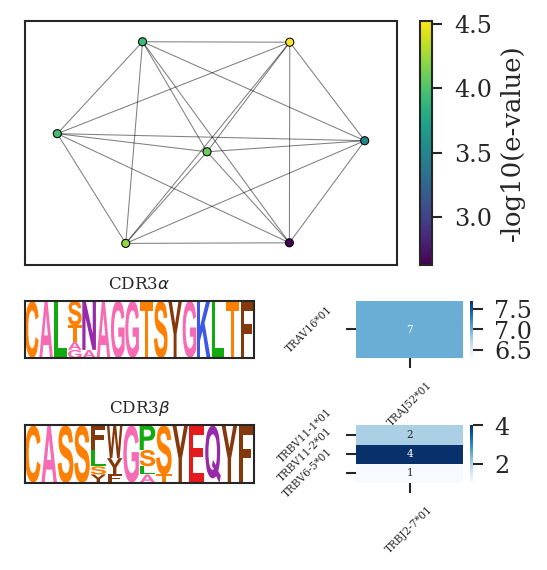

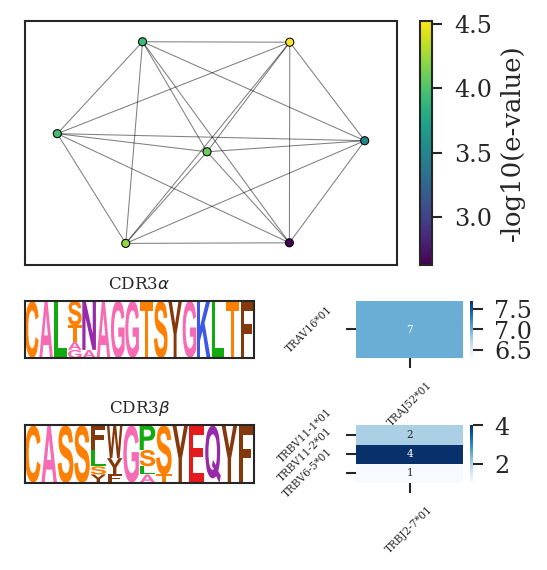

In [370]:
# Add fulclone column
clonecols = ['va', 'ja', 'cdr3a', 'cdr3a_nucseq', 'vb', 'jb', 'cdr3b', 'cdr3b_nucseq']
res_pre.data['full_clone'] = res_pre.data.apply(lambda x: '_'.join([str(x[i]) for i in clonecols]), axis=1)
res_acute.data['full_clone'] = res_acute.data.apply(lambda x: '_'.join([str(x[i]) for i in clonecols]), axis=1)
res_conv.data['full_clone'] = res_conv.data.apply(lambda x: '_'.join([str(x[i]) for i in clonecols]), axis=1)

# Cluster SNE clones
res_pre.get_clusters(100, periphery=False)
res_acute.get_clusters(100, periphery=False)
res_conv.get_clusters(100, periphery=False)

sign_pre = res_pre.data[res_pre.data['evalue']<.05]
sign_acute = res_acute.data[res_acute.data['evalue']<.05]
sign_conv = res_conv.data[res_conv.data['evalue']<.05]

Encoding TCRs took 0.03s
Building the index took 0.00s
Searching index within radius 100 took 0.08s
Building the sparse matrix took 0.01s
Total time to compute distance matrix: 0.33s
Encoding TCRs took 0.01s
Building the index took 0.00s
Searching index within radius 100 took 0.05s
Building the sparse matrix took 0.00s
Total time to compute distance matrix: 0.32s
Encoding TCRs took 0.02s
Building the index took 0.00s
Searching index within radius 100 took 0.09s
Building the sparse matrix took 0.01s
Total time to compute distance matrix: 0.32s


In [371]:
# sign_acute



,pvalue,evalue,tcr_index,radius,num_nbrs,expected_num_nbrs,bg_nbrs,timepoint,wi,wj,...,loss_b_frac,score,cdr3a,va,ja,cdr3b,vb,jb,cluster,full_clone
165,1.351574e-10,0.000003,3353,100,7,0.133750,256366.0,cd4_acute,0,0,...,0.000000,0.182261,CATGSSNAGNMLTF,TRAV17*01,TRAJ39*01,CASSPVPLNSPLHF,TRBV5-1*01,TRBJ1-6*01,1,TRAV17*01_TRAJ39*01_CATGSSNAGNMLTF_tgtgctacggg...
174,3.600694e-09,0.000069,3592,100,8,0.344204,659756.0,cd4_acute,0,0,...,0.000000,0.182261,CATGPRNAGNMLTF,TRAV17*01,TRAJ39*01,CASSLTPMNTEAFF,TRBV5-1*01,TRBJ1-1*01,1,TRAV17*01_TRAJ39*01_CATGPRNAGNMLTF_tgtgctacggg...
175,3.600694e-09,0.000069,3593,100,8,0.344204,659756.0,cd4_acute,0,0,...,0.000000,0.182261,CATGPRNAGNMLTF,TRAV17*01,TRAJ39*01,CASSLTPMNTEAFF,TRBV5-1*01,TRBJ1-1*01,1,TRAV17*01_TRAJ39*01_CATGPRNAGNMLTF_tgtgctacggg...
176,3.600694e-09,0.000069,3594,100,8,0.344204,659756.0,cd4_acute,0,0,...,0.000000,0.182261,CATGPRNAGNMLTF,TRAV17*01,TRAJ39*01,CASSLTPMNTEAFF,TRBV5-1*01,TRBJ1-1*01,1,TRAV17*01_TRAJ39*01_CATGPRNAGNMLTF_tgtgctacggg...
221,1.109899e-10,0.000002,4415,100,13,1.047279,2007382.0,cd4_acute,0,0,...,0.000000,1.873915,CALDKDSSASKIIF,TRAV6*01,TRAJ3*01,CSARGGTTETQYF,TRBV20-1*01,TRBJ2-5*01,0,TRAV6*01_TRAJ3*01_CALDKDSSASKIIF_tgtgctctagaca...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1387,2.059685e-08,0.000395,18459,100,5,0.076583,146792.0,cd4_acute,13,11,...,0.302326,4.201950,CAVPSTDKLIF,TRAV41*01,TRAJ34*01,CASSGQGTTNEKLFF,TRBV18*01,TRBJ1-4*01,3,TRAV41*01_TRAJ34*01_CAVPSTDKLIF_tgtgctgtcccgag...
1389,2.979627e-09,0.000057,18467,100,5,0.051810,99308.0,cd4_acute,13,14,...,0.250000,5.956936,CAVPRDDKIIF,TRAV41*01,TRAJ30*01,CASSLQGITNTEAFF,TRBV18*01,TRBJ1-1*01,3,TRAV41*01_TRAJ30*01_CAVPRDDKIIF_tgtgctgttcccag...
1418,1.307243e-08,0.000251,18659,100,4,0.023780,45580.0,cd4_acute,15,47,...,0.120000,1.582947,CAVEDRSNYGQNFVF,TRAV2*01,TRAJ26*01,CASSQQAGGYNEQFF,TRBV14*01,TRBJ2-1*01,11,TRAV2*01_TRAJ26*01_CAVEDRSNYGQNFVF_tgtgctgtgga...
1421,1.264118e-09,0.000024,18678,100,6,0.099857,191401.0,cd4_acute,16,2,...,0.470588,6.320544,CALTNAGGTSYGKLTF,TRAV16*01,TRAJ52*01,CASSFYGSSYEQYF,TRBV11-2*01,TRBJ2-7*01,2,TRAV16*01_TRAJ52*01_CALTNAGGTSYGKLTF_tgtgctcta...


In [59]:
print('Pre <-> Acute')
print(set(sign_pre.full_clone).intersection(set(sign_acute.full_clone)))
print(set(sign_pre.alpha_clone).intersection(set(sign_acute.alpha_clone)))
print(set(sign_pre.beta_clone).intersection(set(sign_acute.beta_clone)))
print(set(sign_pre.alpha_clone).intersection(set(acute.alpha_clone)))
print(set(sign_pre.beta_clone).intersection(set(acute.beta_clone)))
print(set(sign_pre.full_clone).intersection(set(acute.full_clone)))

print('\nPre <-> Convalescent')
print(set(sign_pre.full_clone).intersection(set(sign_conv.full_clone)))
print(set(sign_pre.alpha_clone).intersection(set(sign_conv.alpha_clone)))
print(set(sign_pre.beta_clone).intersection(set(sign_conv.beta_clone)))
print(set(sign_pre.alpha_clone).intersection(set(conv.alpha_clone)))
print(set(sign_pre.beta_clone).intersection(set(conv.beta_clone)))
print(set(sign_pre.full_clone).intersection(set(conv.full_clone)))

print('\nAcute <-> Convalescent')
print(set(sign_acute.full_clone).intersection(set(sign_conv.full_clone)))
print(set(sign_acute.alpha_clone).intersection(set(sign_conv.alpha_clone)))
print(set(sign_acute.beta_clone).intersection(set(sign_conv.beta_clone)))
print(set(sign_acute.full_clone).intersection(set(conv.full_clone)))
print(set(sign_acute.alpha_clone).intersection(set(conv.alpha_clone)))
print(set(sign_acute.beta_clone).intersection(set(conv.beta_clone)))

Pre <-> Acute
{'TRAV6*01_CALDGGGTASKLTF_TRAJ44*01_TRBV20-1*01_CSARGGILETQYF_TRBJ2-5*01', 'TRAV13-1*01_CAASPNGGATNKLIF_TRAJ32*01_TRBV10-3*01_CATTDSVYYTF_TRBJ1-2*01', 'TRAV41*01_CAVPNTDKLIF_TRAJ34*01_TRBV18*01_CASSAQGPANTEAFF_TRBJ1-1*01', 'TRAV13-1*01_CAASQNGGATNKLIF_TRAJ32*01_TRBV10-3*01_CATAGAYEQYF_TRBJ2-7*01', 'TRAV6*01_CALDQAGTASKLTF_TRAJ44*01_TRBV20-1*01_CSARTGLTEKLFF_TRBJ1-4*01', 'TRAV6*01_CALDMGGSASKIIF_TRAJ3*01_TRBV20-1*01_CSARGQVTETQYF_TRBJ2-5*01', 'TRAV41*01_CAVPSTDKLIF_TRAJ34*01_TRBV18*01_CASSGQGTTNEKLFF_TRBJ1-4*01', 'TRAV6*01_CALDKDSSASKIIF_TRAJ3*01_TRBV20-1*01_CSARGGTTETQYF_TRBJ2-5*01', 'TRAV41*01_CAVPRDDKIIF_TRAJ30*01_TRBV18*01_CASSLQGITNTEAFF_TRBJ1-1*01', 'TRAV41*01_CAVAMNRDDKIIF_TRAJ30*01_TRBV5-1*01_CASSKTGTNTYNEQFF_TRBJ2-1*01', 'TRAV10*01_CVVSASGNQFYF_TRAJ49*01_TRBV24-1*01_CATSEPDSSSYNEQFF_TRBJ2-1*01', 'TRAV26-1*01_CIVRVAGGNAGNMLTF_TRAJ39*01_TRBV20-1*01_CSALHLMGEAFF_TRBJ1-1*01', 'TRAV41*01_CAVSRNRDDKIIF_TRAJ30*01_TRBV5-1*01_CASNRPGGSSYNEQFF_TRBJ2-1*01', 'TRAV16*01_CALANA

/tmp/ipykernel_1337942/2112482071.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  node_data['color'] = node_data.full_clone.apply(lambda x: 'tab:blue' if x in persistent else 'tab:grey')
/tmp/ipykernel_1337942/2112482071.py:22: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, c=c, cmap='viridis', s=s, edgecolors='black', linewidths=0.5)
/tmp/ipykernel_1337942/2112482071.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  node_data['color'] = no

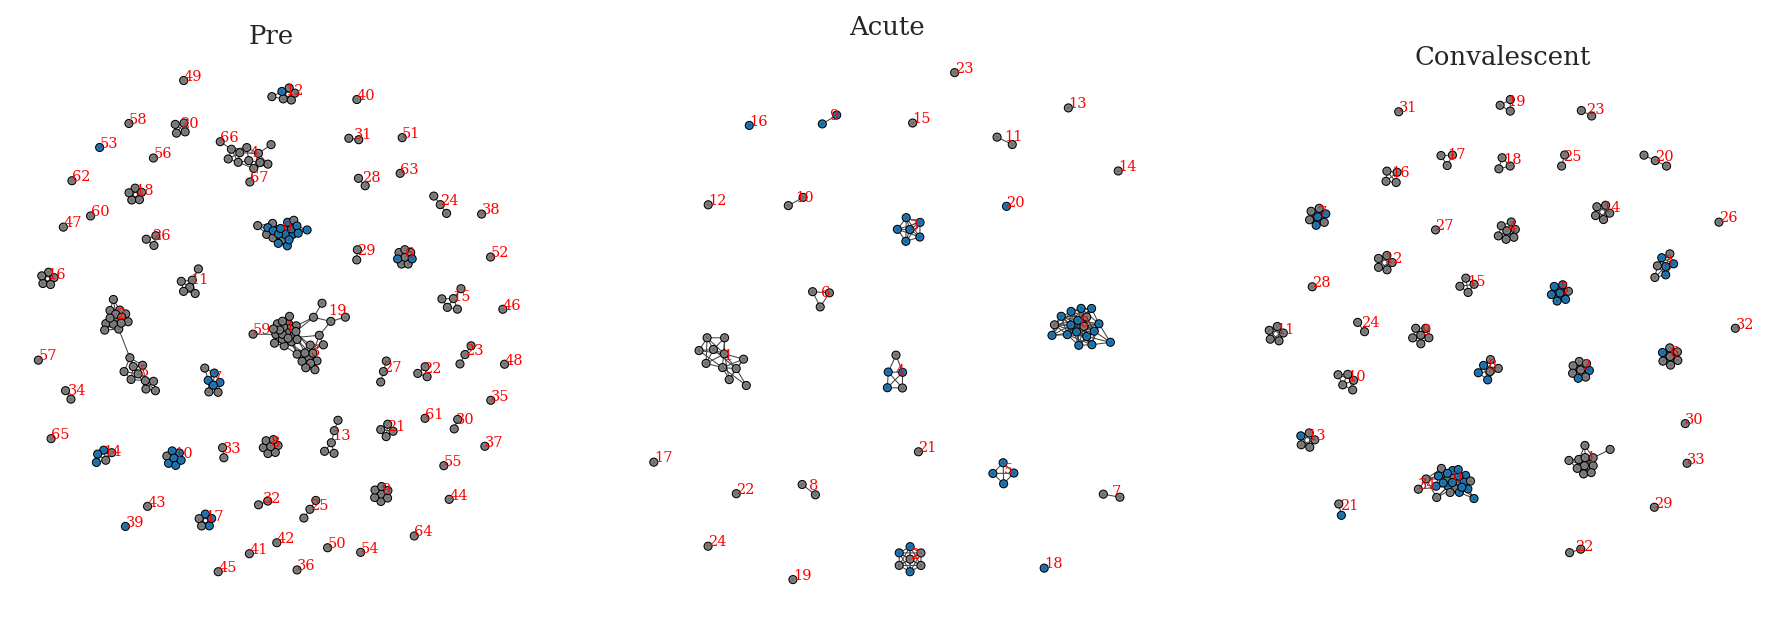

In [352]:
def annotate_network(res, persistent, ax=None, size=True):

        layout = res.Gi.layout("graphopt", niter=1000)

        node_data = res.data.iloc[[i['_nx_name'] for i in res.Gi.vs]]
        node_data['color'] = node_data.full_clone.apply(lambda x: 'tab:blue' if x in persistent else 'tab:grey')

        x = [i[0] for i in layout]
        y = [i[1] for i in layout]

        visual_style = {'edge_width': 0.5,}
        ig.plot(res.Gi,
                layout=layout,
                **visual_style,
                target=ax)

        c = node_data['color']
        if size:
                s = -np.log10(node_data.evalue) * 2
        else:
                s = 15
        ax.scatter(x, y, c=c, cmap='viridis', s=s, edgecolors='black', linewidths=0.5)

        return c, layout

def add_cluster_labels(res, layout, ax):

        x = [i[0] for i in layout]
        y = [i[1] for i in layout]

        node_data = res.data.iloc[[i['_nx_name'] for i in res.Gi.vs]]

        node_data['x_coord'] = x
        node_data['y_coord'] = y

        for clus in node_data.cluster.unique():
                cluster = node_data[node_data.cluster==clus]
                ax.text(
                        x=cluster.x_coord.mean(), 
                        y=cluster.y_coord.mean(),
                        s=str(clus),
                        c='red',
                        fontsize=7
                )

persistent = set(sign_pre.full_clone).intersection(set(sign_acute.full_clone)).intersection(set(sign_conv.full_clone))

fig, ax = plt.subplots(dpi=150, figsize=(15,5), ncols=3)

c1, layout1 = annotate_network(res_pre, persistent, ax=ax[0], size=False)
c2, layout2 = annotate_network(res_acute, persistent, ax=ax[1], size=False)
c3, layout3 = annotate_network(res_conv, persistent, ax=ax[2], size=False)

add_cluster_labels(res_pre, layout1, ax[0])
add_cluster_labels(res_acute, layout2, ax[1])
add_cluster_labels(res_conv, layout3, ax[2])

ax[0].set_title('Pre')
ax[1].set_title('Acute')
ax[2].set_title('Convalescent')

fig.savefig('../sne_manuscript/manuscript_figures/tirtl_sne_network_cd4_persistent.svg', bbox_inches='tight', format='svg')

In [61]:
print(len(persistent) / pre.shape[0])
print(len(persistent) / acute.shape[0])
print(len(persistent) / conv.shape[0])

print(len(persistent) / sign_pre.shape[0])
print(len(persistent) / sign_acute.shape[0])
print(len(persistent) / sign_conv.shape[0])

0.0010969379759927288
0.0018251981643721319
0.0013904338153503894
0.14056224899598393
0.44871794871794873
0.22727272727272727


In [286]:
(sign_acute.shape[0] / acute.shape[0]) * 100

0.41197329995828114

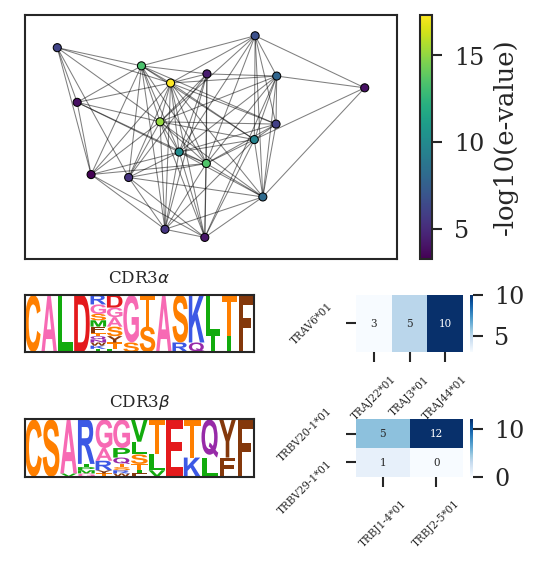

In [355]:
fig = res_acute.draw_cluster(0)
fig.savefig('../sne_manuscript/manuscript_figures/tirtl_sne_cluster_0_cd4_persistent.svg', bbox_inches='tight', format='svg')

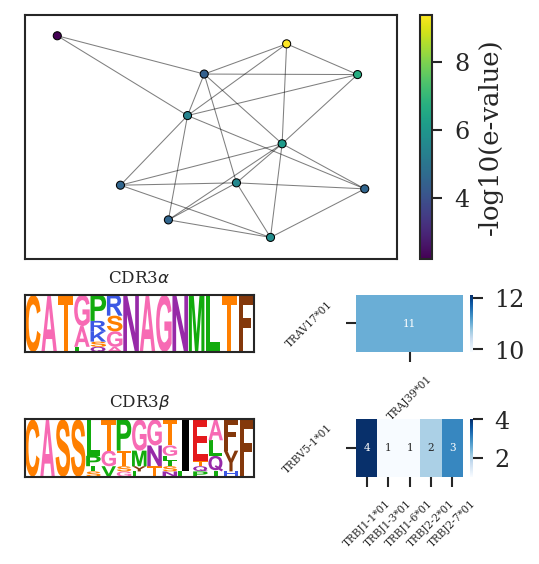

In [356]:
fig = res_acute.draw_cluster(1)
fig.savefig('../sne_manuscript/manuscript_figures/tirtl_sne_cluster_1_cd4.svg', bbox_inches='tight', format='svg')

,timepoint,wi,wj,wij,alpha_nuc,beta_nuc,wa,wb,cdr3a_nucseq,cdr3b_nucseq,...,pval_adj,loss_a_frac,loss_b_frac,score,cdr3a,va,ja,cdr3b,vb,jb
0,cd8_acute,0,0,3,TGTGCTACGGACGCGGAAACCGGCACTGCCAGTAAACTCACCTTT,TGTGCCAGCAGCGTAGCTCTGTCAGGGGGCTTCTATGGCTACACCTTC,3,3,TGTGCTACGGACGCGGAAACCGGCACTGCCAGTAAACTCACCTTT,TGTGCCAGCAGCGTAGCTCTGTCAGGGGGCTTCTATGGCTACACCTTC,...,NaN,0.000000,0.000000,0.417523,CATDAETGTASKLTF,TRAV17*01,TRAJ44*01,CASSVALSGGFYGYTF,TRBV9*01,TRBJ1-2*01
1,cd8_acute,0,0,3,TGTGCTCTCCAGGGGAATAACAATGCCAGACTCATGTTT,TGCGCCAGCAGCTTGGCCGGAGTTCACAGGACCACAGATACGCAGT...,3,3,TGTGCTCTCCAGGGGAATAACAATGCCAGACTCATGTTT,TGCGCCAGCAGCTTGGCCGGAGTTCACAGGACCACAGATACGCAGT...,...,NaN,0.000000,0.000000,0.417523,CALQGNNNARLMF,TRAV21*01,TRAJ31*01,CASSLAGVHRTTDTQYF,TRBV5-1*01,TRBJ2-3*01
2,cd8_acute,0,0,3,TGTGCTCTCCTCCTTGTTTCAGATGGCCAGAAGCTGCTCTTT,TGCGCCAGCAGCTTGGCCGGAGTTCACAGGACCACAGATACGCAGT...,3,3,TGTGCTCTCCTCCTTGTTTCAGATGGCCAGAAGCTGCTCTTT,TGCGCCAGCAGCTTGGCCGGAGTTCACAGGACCACAGATACGCAGT...,...,NaN,0.000000,0.000000,0.417523,CALLLVSDGQKLLF,TRAV6*01,TRAJ16*01,CASSLAGVHRTTDTQYF,TRBV5-1*01,TRBJ2-3*01
3,cd8_acute,0,0,3,TGTGCTGTGAGTCAGAAGAACAGAGATGACAAGATCATCTTT,TGCAGCGTCCGACTAGCGGGAGAAACCGAGCAGTACTTC,3,3,TGTGCTGTGAGTCAGAAGAACAGAGATGACAAGATCATCTTT,TGCAGCGTCCGACTAGCGGGAGAAACCGAGCAGTACTTC,...,NaN,0.000000,0.000000,0.417523,CAVSQKNRDDKIIF,TRAV8-6*01,TRAJ30*01,CSVRLAGETEQYF,TRBV29-1*01,TRBJ2-7*01
4,cd8_acute,0,0,3,TGTGCGCCTTATAACCAGGGAGGAAAGCTTATCTTC,TGTGCCAGCAGCTCGGGACTGACGAACACTGAAGCTTTCTTT,3,3,TGTGCGCCTTATAACCAGGGAGGAAAGCTTATCTTC,TGTGCCAGCAGCTCGGGACTGACGAACACTGAAGCTTTCTTT,...,NaN,0.000000,0.000000,0.417523,CAPYNQGGKLIF,TRAV12-3*01,TRAJ23*01,CASSSGLTNTEAFF,TRBV3-1*01,TRBJ1-1*01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9307,cd8_acute,76,0,41,TGTGCTGTGAGTGAGGGCTACAAGCTCAGCTTT,TGCGCCAGCAGCTTGGGACAGGGAGGCAACCAGCCCCAGCATTTT,117,41,TGTGCTGTGAGTGAGGGCTACAAGCTCAGCTTT,TGCGCCAGCAGCTTGGGACAGGGAGGCAACCAGCCCCAGCATTTT,...,NaN,0.000000,0.649573,4.604051,CAVSEGYKLSF,TRAV8-6*01,TRAJ20*01,CASSLGQGGNQPQHF,TRBV5-1*01,TRBJ1-5*01
9308,cd8_acute,78,0,18,TGTGCTGTGTTGGATAGCAACTATCAGTTAATCTGG,TGTGCCAGCAGCCAAGAAGGCGGGGGGGACTACAATGAGCAGTTCTTC,96,18,TGTGCTGTGTTGGATAGCAACTATCAGTTAATCTGG,TGTGCCAGCAGCCAAGAAGGCGGGGGGGACTACAATGAGCAGTTCTTC,...,NaN,0.000000,0.812500,0.157466,CAVLDSNYQLIW,TRAV1-2*01,TRAJ33*01,CASSQEGGGDYNEQFF,TRBV4-2*01,TRBJ2-1*01
9309,cd8_acute,85,1,29,TGTGCTGCTATGGATAGCAACTATCAGTTAATCTGG,TGCAGTGCTAAACTAGCGGGGGGAATAAGGATCCAAGAGACCCAGT...,114,30,TGTGCTGCTATGGATAGCAACTATCAGTTAATCTGG,TGCAGTGCTAAACTAGCGGGGGGAATAAGGATCCAAGAGACCCAGT...,...,NaN,0.008696,0.739130,0.522454,CAAMDSNYQLIW,TRAV1-2*01,TRAJ33*01,CSAKLAGGIRIQETQYF,TRBV20-1*01,TRBJ2-5*01
9310,cd8_acute,95,0,36,TGCATCCTGAGAGAAGGGGGGAGTGACATGCGCTTT,TGTGCCAGCAGCTTATGGGGGGGGGGGGACACTGAAGCTTTCTTT,131,36,TGCATCCTGAGAGAAGGGGGGAGTGACATGCGCTTT,TGTGCCAGCAGCTTATGGGGGGGGGGGGACACTGAAGCTTTCTTT,...,NaN,0.000000,0.725191,1.073628,CILREGGSDMRF,TRAV26-2*01,TRAJ43*01,CASSLWGGGDTEAFF,TRBV7-2*01,TRBJ1-1*01


Though unlikely, see if we can assign some class II epitopes to these clusters. Use IMW DETECT for this (code down below at the end of this notebook).

In [288]:
imw = run_imw_detect(res_acute.data[res_acute.data.cluster==1])
imw_sign = imw[imw.Score > 0.23]
long_to_paired(imw_sign)

/tmp/ipykernel_1337942/1612300740.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={'va': 'v_call_alpha', 'cdr3a': 'junction_aa_alpha', 'ja': 'j_call_alpha',


Input repertoire is /home/sebastiaan/phd/repositories/immune_response_detection/data/imw_data_chunk_0.tsv
TCR database is imwdb
Output file is /home/sebastiaan/phd/repositories/immune_response_detection/data/imw_out_chunk_0.tsv
ImmuneWatch DETECT version 1.3.0
Running standard annotation mode
AIRR compliant file detected
Running paired chain predictions by column cell_id
License validated
100% 24/24 [00:00<00:00, 313.16it/s]
Predictions written to /home/sebastiaan/phd/repositories/immune_response_detection/data/imw_out_chunk_0.tsv


,va,cdr3a,ja,vb,cdr3b,jb,Epitope,Score,Antigen,Species,HLA,Reference TCRs


Perhaps we can assign some HLA restriction to the clusters through comparing them with the TCRs in the CMV ecocluster. Of course now we're betting on wether this subject is CMV seropositive or not.

In [350]:
cmv_ecocluster = pd.read_table('/home/sebastiaan/phd/data/cmv_ecocluster/cmv_ecocluster_parsed.tsv')
cmv_ecocluster['beta_clone'] = cmv_ecocluster.apply(lambda x: '_'.join([str(x[i]) for i in ['junction_aa','v_call','j_call']]), axis=1)

sign_acute['beta_clone'] = sign_acute.apply(lambda x: '_'.join([str(x[i]) for i in ['cdr3b','vb','jb']]), axis=1)
set(sign_acute.cdr3b).intersection(set(cmv_ecocluster.junction_aa))

hla_inferred = pd.read_table('./data/inference_all_data_TCRs_sign_HLA.tsv')
sign_acute['TCR+V'] = sign_acute.apply(lambda x: x.cdr3b + '+' + x.vb.split('*')[0].split('-')[0], axis=1)

set(sign_acute['TCR+V']).intersection(set(hla_inferred['TCR+V']))

hla_inferred[hla_inferred['TCR+V']=='CSVEGGSGANVLTF+TRBV29']

# sign_acute.merge(cmv_ecocluster, on='beta_clone')

/tmp/ipykernel_1337942/3643399007.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sign_acute['beta_clone'] = sign_acute.apply(lambda x: '_'.join([str(x[i]) for i in ['cdr3b','vb','jb']]), axis=1)
/tmp/ipykernel_1337942/3643399007.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sign_acute['TCR+V'] = sign_acute.apply(lambda x: x.cdr3b + '+' + x.vb.split('*')[0].split('-')[0], axis=1)


,TCR+V,p_BH,TCR_sharing,HLA $\cap$ TCRs,HLA,chain,Attribute
7858,CSVEGGSGANVLTF+TRBV29,0.026834,122.0,42.0,B*08:01,beta,Overrepresented
10372,CSVEGGSGANVLTF+TRBV29,0.026210,122.0,52.0,C*07:01,beta,Overrepresented


^^ Only two associations, but they are class I...

In [390]:
longi_cd4 = pd.read_table('./data/cd4_tp1_tp2_longitudinal_beta.tsv')
# longi_cd4['nSeqCDR3'] = longi_cd4['nSeqCDR3'].str.lower()

longi_cd4_data = longi_cd4[['nSeqCDR3','avg.y','log2FC']].merge(acute, left_on='nSeqCDR3', right_on='cdr3b_nucseq')
commoncols = set(longi_data.columns).intersection(res_acute.data.columns)

merged_all = longi_cd4_data.merge(res_acute.data, on=list(commoncols), how='left')
merged_res = longi_cd4_data.merge(res_acute.data, on=list(commoncols), how='inner')
# merged_all['pvalue'] = merged_all.pvalue.fillna(1)

merged_all['log10pval'] = -np.log10(merged_all.pvalue)
merged_res['log10pval'] = -np.log10(merged_res.pvalue)

expanders = merged_all[merged_all.log2FC>3].reset_index(drop=True)
expanders['full_clone'] = expanders.apply(lambda x: '_'.join([str(x[i]) for i in clonecols]), axis=1)

In [403]:
longi_cd4 = pd.read_table('./data/cd4_tp1_tp2_longitudinal_beta.tsv')
# longi_cd4['nSeqCDR3'] = longi_cd4['nSeqCDR3'].str.lower()

longi_cd4_data = longi_cd4[['nSeqCDR3','avg.y','log2FC']].merge(acute, left_on='nSeqCDR3', right_on='cdr3b_nucseq')
commoncols = set(longi_data.columns).intersection(res_acute.data.columns)

cd4_expanded = longi_cd4_data[longi_cd4_data.log2FC > 3]
cd4_expanded['cdr3a_nucseq'] = cd4_expanded['cdr3a_nucseq'].str.lower()
cd4_expanded['cdr3b_nucseq'] = cd4_expanded['cdr3b_nucseq'].str.lower()
cd4_expanded['full_clone'] = cd4_expanded.apply(lambda x: '_'.join([str(x[i]) for i in clonecols]), axis=1)

cd4_expanded

/tmp/ipykernel_1337942/2622958324.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cd4_expanded['cdr3a_nucseq'] = cd4_expanded['cdr3a_nucseq'].str.lower()
/tmp/ipykernel_1337942/2622958324.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cd4_expanded['cdr3b_nucseq'] = cd4_expanded['cdr3b_nucseq'].str.lower()
/tmp/ipykernel_1337942/2622958324.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See th

,nSeqCDR3,avg.y,log2FC,timepoint,wi,wj,wij,alpha_nuc,beta_nuc,wa,...,loss_a_frac,loss_b_frac,score,cdr3a,va,ja,cdr3b,vb,jb,full_clone
16,TGCAGCGAACTTTCGACAGAGAACACTGAAGCTTTCTTT,0.000022,4.529120,cd4_acute,0,1,4,TGTGCTGTGAGGGGCCGGAATACTGGAGGCTTCAAAACTATCTTT,TGCAGCGAACTTTCGACAGAGAACACTGAAGCTTTCTTT,4,...,0.200000,0.000000,1.238143,CAVRGRNTGGFKTIF,TRAV8-6*01,TRAJ9*01,CSELSTENTEAFF,TRBV29-1*01,TRBJ1-1*01,TRAV8-6*01_TRAJ9*01_CAVRGRNTGGFKTIF_tgtgctgtga...
23,TGCAGCGCCAAAGGGACAGGGAATTATCAGCCCCAGCATTTT,0.000016,3.171183,cd4_acute,0,0,4,TGTGCCCGTGCGGGCTCAGGAACCTACAAATACATCTTT,TGCAGCGCCAAAGGGACAGGGAATTATCAGCCCCAGCATTTT,4,...,0.000000,0.000000,1.873915,CARAGSGTYKYIF,TRAV16*01,TRAJ40*01,CSAKGTGNYQPQHF,TRBV29-1*01,TRBJ1-5*01,TRAV16*01_TRAJ40*01_CARAGSGTYKYIF_tgtgcccgtgcg...
24,TGCAGCGCCAAAGGGACAGGGAATTATCAGCCCCAGCATTTT,0.000016,3.171183,cd4_acute,0,0,4,TGTGCAGCAAGTGTTGCCCTTTGGAACCAGGGAGGAAAGCTTATCTTC,TGCAGCGCCAAAGGGACAGGGAATTATCAGCCCCAGCATTTT,4,...,0.000000,0.000000,1.873915,CAASVALWNQGGKLIF,TRAV13-1*01,TRAJ23*01,CSAKGTGNYQPQHF,TRBV29-1*01,TRBJ1-5*01,TRAV13-1*01_TRAJ23*01_CAASVALWNQGGKLIF_tgtgcag...
32,TGCAGCGCCGGCGGGTCGTCTGGGGCCAACGTCCTGACTTTC,0.000380,8.561797,cd4_acute,0,19,35,TGTGCAGTCCCCCCAAATTCCGGGTATGCACTCAACTTC,TGCAGCGCCGGCGGGTCGTCTGGGGCCAACGTCCTGACTTTC,35,...,0.351852,0.000000,18.415311,CAVPPNSGYALNF,TRAV25*01,TRAJ41*01,CSAGGSSGANVLTF,TRBV29-1*01,TRBJ2-6*01,TRAV25*01_TRAJ41*01_CAVPPNSGYALNF_tgtgcagtcccc...
59,TGCAGCGGAAGGGACAGGGTGGACACTGAAGCTTTCTTT,0.000036,5.190889,cd4_acute,0,3,5,TGTGCAGCCTGGAGTGCTGGCAACAACCGTAAGCTGATTTGG,TGCAGCGGAAGGGACAGGGTGGACACTGAAGCTTTCTTT,5,...,0.375000,0.000000,1.788437,CAAWSAGNNRKLIW,TRAV13-1*01,TRAJ38*01,CSGRDRVDTEAFF,TRBV29-1*01,TRBJ1-1*01,TRAV13-1*01_TRAJ38*01_CAAWSAGNNRKLIW_tgtgcagcc...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13602,TGTGCCTGGGGGGGGGGAAAGTCAGTCTACAATGAGCAGTTCTTC,0.000025,4.722058,cd4_acute,0,0,10,TGTGCTCTAAAAGAAACCTCCTACGACAAGGTGATATTT,TGTGCCTGGGGGGGGGGAAAGTCAGTCTACAATGAGCAGTTCTTC,10,...,0.000000,0.000000,10.389594,CALKETSYDKVIF,TRAV16*01,TRAJ50*01,CAWGGGKSVYNEQFF,TRBV30*01,TRBJ2-1*01,TRAV16*01_TRAJ50*01_CALKETSYDKVIF_tgtgctctaaaa...
13609,TGTGCCTGGTCCAGGGGACAGGGTAAGGGGAAACGGGGAACAGATA...,0.000027,4.830475,cd4_acute,47,1,48,TGTGCTGTGGGGGGCTACAATAAGCTGATTTTT,TGTGCCTGGTCCAGGGGACAGGGTAAGGGGAAACGGGGAACAGATA...,95,...,0.010417,0.489583,10.836851,CAVGGYNKLIF,TRAV2*01,TRAJ4*01,CAWSRGQGKGKRGTDTQYF,TRBV30*01,TRBJ2-3*01,TRAV2*01_TRAJ4*01_CAVGGYNKLIF_tgtgctgtggggggct...
13627,TGTGCTAGCAGCCCCGAGGTAGCGGGAGCGGGTGAGACCCAGTACTTC,0.000010,3.398715,cd4_acute,6,0,5,TGTGCTGTGATTACCTCAGGAACCTACAAATACATCTTT,TGTGCTAGCAGCCCCGAGGTAGCGGGAGCGGGTGAGACCCAGTACTTC,11,...,0.000000,0.545455,0.856671,CAVITSGTYKYIF,TRAV22*01,TRAJ40*01,CASSPEVAGAGETQYF,TRBV7-7*01,TRBJ2-5*01,TRAV22*01_TRAJ40*01_CAVITSGTYKYIF_tgtgctgtgatt...
13645,TGTGCTAGCAGTTGGGGGTTAGGGCACACTGAAGCTTTCTTT,0.000060,5.929531,cd4_acute,17,11,20,TGTGCTTATAGGAGTGTTGATAGCAACTATCAGTTAATCTGG,TGTGCTAGCAGTTGGGGGTTAGGGCACACTGAAGCTTTCTTT,37,...,0.229167,0.354167,3.394407,CAYRSVDSNYQLIW,TRAV38-2/DV8*01,TRAJ33*01,CASSWGLGHTEAFF,TRBV7-7*01,TRBJ1-1*01,TRAV38-2/DV8*01_TRAJ33*01_CAYRSVDSNYQLIW_tgtgc...


,nSeqCDR3,avg.x,sem.x,wells.x,avg_well.x,avg.y,sem.y,wells.y,avg_well.y,log2FC,sign
0,AGAACACTGAAGCTCTCTTT,7.807048e-08,3.889523e-08,5,0.000003,0.000000e+00,3.138981e-06,0,0.000000,-0.108451,stable
1,AGCAGTGCTAGAGTGATGAGTGGCAGGGGTTCTGGCTACGAGCAGT...,1.122778e-06,4.939702e-07,11,0.000020,0.000000e+00,3.138981e-06,0,0.000000,-1.085954,stable
2,AGTACGAACATAGGGCCAGGGGAGACCCAGTACTTC,0.000000e+00,3.608771e-06,0,0.000000,1.747279e-06,1.093985e-06,12,0.000028,1.458004,stable
3,CAAGACGTAGCTGGACAGTACTATGGCTACACCTTC,2.138292e-07,1.039919e-07,6,0.000007,1.635027e-06,3.138981e-06,1,0.000314,1.118253,stable
4,CCCGGGGGGCATCGGAGTCCGCATCTACAATGAGCAGTTCTTC,1.078853e-07,3.608771e-06,2,0.000010,5.019117e-07,2.535648e-07,5,0.000019,0.438992,stable
...,...,...,...,...,...,...,...,...,...,...,...
92848,TTCCGGGGCGTTGGACTATGGCTACACCTTC,5.784367e-07,2.951079e-07,5,0.000022,5.545778e-07,2.510324e-07,6,0.000018,-0.021974,stable
92849,TTCGGACACAGGAATTCACCCCTCCACTTT,0.000000e+00,3.608771e-06,0,0.000000,3.600552e-07,1.736075e-07,6,0.000012,0.443665,stable
92850,TTGATTTTCTACTCCTACAATGAGCAGTTCTTC,4.252254e-07,1.974362e-07,5,0.000016,0.000000e+00,3.138981e-06,0,0.000000,-0.511190,stable
92851,TTGTGCTAGTGGTTTGTATCAGGGGGCGTCAGATACGCAGTATTTT,2.596130e-07,1.169122e-07,5,0.000010,5.798032e-08,3.138981e-06,1,0.000011,-0.251668,stable


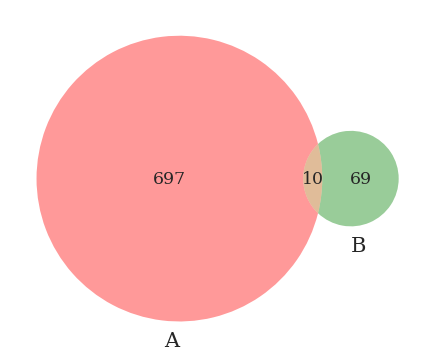

In [404]:
venn2((set(cd4_expanded.full_clone), set(sign_acute.full_clone)))

longi_cd4

In [ ]:
col_remap = {
    'junction_aa_alpha':'cdr3a', 
    'v_call_alpha':'va', 
    'j_call_alpha':'ja', 
    'junction_aa_beta':'cdr3b',
    'v_call_beta':'vb',
    'j_call_beta':'jb'
}

if col_remap.keys()[0] in sne_pre.columns:
    sne_pre = res_pre.data.rename(columns=col_remap)

encoder = TCRDistEncoder(aa_dim=16, chain='AB').fit()
qvecs = encoder.transform(sne_pre)
rvecs = encoder.transform(vdjdb_paired)

index = faiss.IndexFlatL2(qvecs.shape[1])
index.add(rvecs)

lims, D, I = index.range_search(qvecs, thresh=90)
edges = convert_range_search_output(lims, D, I)

edges = [(str(i[0][0]) + '_SNE', str(i[0][1]) + '_VDJDB', i[1]) for i in edges]

species_color = {
    'InfluenzaA':'#ec7063',
    'SARS-CoV-2':'#85c1e9',
    'CMV':'#7dcea0',
    'HCV':'#961cea',
    'HomoSapiens':'#fcb5eb',
    'EBV':'#0b5345',
    'YFV':'#f9e79f',
    'Influenza B':'#943126',
    'synthetic':'#b2babb',
    'HCoV-HKU1':'#b2babb',
    'HSV-2':'#b2babb',
    'HIV-1':'#b2babb',
    'HTLV-1':'#b2babb',
    'MCPyV':'#b2babb',
    'SaccharomycesCerevisiae':'#b2babb'
}

annotated = [int(i.split('_')[0]) for i in nodenames if 'SNE' in i]
annotated = sne_pre.loc[annotated]

# Sample evalue range based on the specified transformation
evalue_min = (-np.log10(annotated.evalue)).min()
evalue_max = (-np.log10(annotated.evalue)).max()

# Normalize the range of evalues
norm = Normalize(vmin=evalue_min, vmax=evalue_max)

# Create a ScalarMappable to map the values to the viridis colormap
viridis_cmap = cm.ScalarMappable(norm=norm, cmap='viridis')

nodes = []
for i in edges:
    nodes += i[:2]
nodes = list(set(nodes))

G = nx.Graph()
G.add_nodes_from(nodes)
G.add_weighted_edges_from(edges)

Gi = ig.Graph.from_networkx(G)

layout = Gi.layout("graphopt", niter=1000)

fig, ax = plt.subplots(dpi=150, figsize=(5,5))

visual_style = {'edge_width': 0.5,}
ig.plot(Gi,
        layout=layout,
        **visual_style,
        target=ax)

x = [i[0] for i in layout]
y = [i[1] for i in layout]

# node_data = data.iloc[]

nodenames = [i['_nx_name'] for i in Gi.vs]

for n, i in enumerate(nodenames):
    if 'SNE' in i:
        evalue = sne_pre.loc[int(i.split('_')[0])]['evalue']
        color = viridis_cmap.to_rgba(-np.log10(evalue))
        ax.scatter(x[n], y[n], color=color,marker='s',s=15, edgecolors='k',linewidths=0.5, zorder=2,alpha=.75)
    else:
        species = vdjdb_paired.loc[int(i.split('_')[0])]['antigen.species']
        color = species_color[species]
        ax.scatter(x[n], y[n], color=color, s=10, edgecolors='k',linewidths=0.5, zorder=1)

# Create a custom legend
legend_color = {
    'InfluenzaA':'#ec7063',
    'SARS-CoV-2':'#85c1e9',
    'CMV':'#7dcea0',
    'HCV':'#961cea',
    'HomoSapiens':'#fcb5eb',
    'EBV':'#0b5345',
    'YFV':'#f9e79f',
    'Influenza B':'#943126',
    'other':'#b2babb',
}

legend_elements = [
    mlines.Line2D([], [], color=color, marker='o', markersize=8, markeredgewidth=0.5, markeredgecolor='black', linestyle='None', label=species)
    for species, color in legend_color.items()
]

square = mlines.Line2D([], [], color='white', marker='s', markersize=12, markeredgewidth=0.5, markeredgecolor='black', linestyle='None', label='query TCR')
legend_elements += [square]

# Add legend to the right of the plot
ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.3, 0.5), frameon=False, title="Legend")

cbar = fig.colorbar(viridis_cmap, ax=ax, shrink=0.5)
cbar.set_label('-log10(evalue)')

This does not make very much sense since all the epitopes in the selected VDJdb dataset are class I-restriced, but to just to get an idea of the baseline.

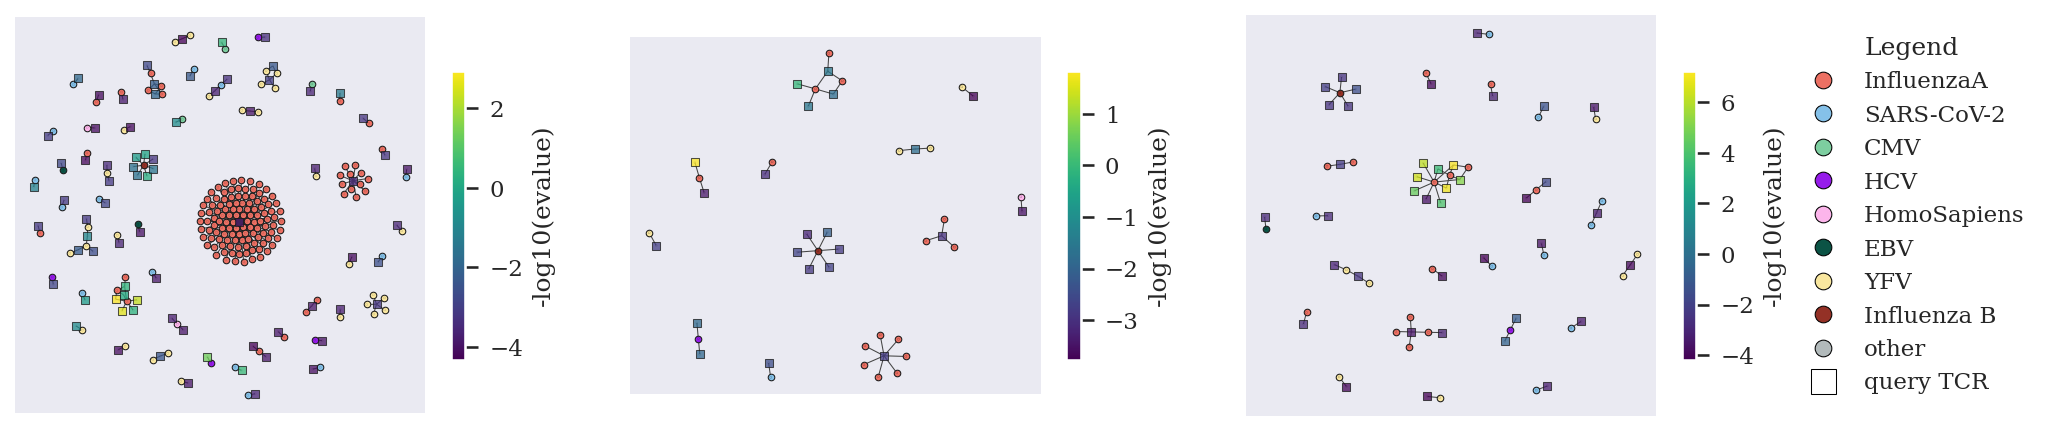

In [374]:
fig, ax = plt.subplots(figsize=(15,5), dpi=150, ncols=3)

vdjdb_annotation_network(res_pre.data, vdjdb_paired, fig=fig, ax=ax[0])
vdjdb_annotation_network(res_acute.data, vdjdb_paired, fig=fig, ax=ax[1])
vdjdb_annotation_network(res_conv.data, vdjdb_paired, fig=fig, ax=ax[2], legend=True)

## CD8 T cells

### **Load CD8 data**

In [8]:
parsed, pre, acute, conv = parse_data('cd8', remove_mait=False)
print('Total CD8 clones:', pre.shape[0] + acute.shape[0] + conv.shape[0])

Remove ambiguous CDR3 amino acid sequences
Parsing V/J genes


/home/sebastiaan/phd/repositories/immune_response_detection/clustcrdist/constants/parsing.py:80: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["junction"] = nt_seq # replace junction column


dropped 0 TCRs with ambiguous junctions


/home/sebastiaan/phd/repositories/immune_response_detection/clustcrdist/constants/parsing.py:80: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["junction"] = nt_seq # replace junction column


dropped 0 TCRs with ambiguous junctions
Total CD8 clones: 26299


/tmp/ipykernel_436488/1716114814.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['is_mait'] = ((data['va'] == 'TRAV1-2*01') & (data['ja'].isin(['TRAJ33*01', 'TRAJ20*01', 'TRAJ12*01'])))


In [16]:
print("clones at baseline:", pre.shape[0])
print("clones at acute:", acute.shape[0])
print("clones at convalescence:", conv.shape[0])

clones at baseline: 8825
clones at acute: 9312
clones at convalescence: 8162


### **Perform SNE analysis**

In [15]:
# Neighbor enrichment analysis
res_pre = neighbor_analysis(pre,'AB','human',100)
res_acute = neighbor_analysis(acute,'AB','human',100)
res_conv = neighbor_analysis(conv,'AB','human',100)

# Cluster SNE clones
res_pre.get_clusters(100, resolution=1e-2)
res_acute.get_clusters(100, resolution=1e-2)
res_conv.get_clusters(100, resolution=1e-2)

# Select SNE clones
sign_pre = res_pre.data[res_pre.data['evalue']<.05]
sign_acute = res_acute.data[res_acute.data['evalue']<.05]
sign_conv = res_conv.data[res_conv.data['evalue']<.05]

Encoding TCRs
Computing neighbor distribution for 8825 TCRs in sample.
Neighbor distribution calculation took 1.96s
Creating background data set with 88250 TCRs
No AIRR format detected, proceeding with paired TCRdist format.
Estimating expected neighbor distribution with the following parameters: dims = 296; maxdist = 100.
paired distribution calc took 14.83
Encoding TCRs
Computing neighbor distribution for 9312 TCRs in sample.
Neighbor distribution calculation took 2.00s
Creating background data set with 93120 TCRs
No AIRR format detected, proceeding with paired TCRdist format.
Estimating expected neighbor distribution with the following parameters: dims = 296; maxdist = 100.
paired distribution calc took 15.51
Encoding TCRs
Computing neighbor distribution for 8162 TCRs in sample.
Neighbor distribution calculation took 1.26s
Creating background data set with 81620 TCRs
No AIRR format detected, proceeding with paired TCRdist format.
Estimating expected neighbor distribution with the fo

### **Investigate MAITs**

With MAIT cells
4.402920962199313
Without MAIT cells
2.2444158075601375


/tmp/ipykernel_436488/3347060530.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sign_acute['is_mait'] = ((sign_acute['va'] == 'TRAV1-2*01') &


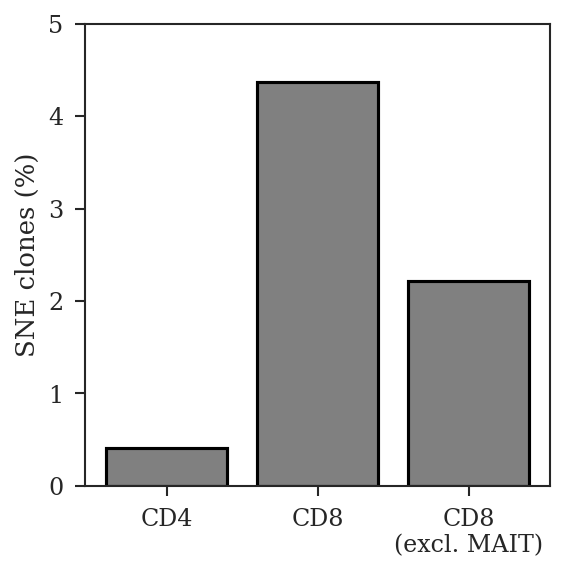

In [17]:
print('With MAIT cells')
print((sign_acute.shape[0] / acute.shape[0]) * 100)

print('Without MAIT cells')
sign_acute['is_mait'] = ((sign_acute['va'] == 'TRAV1-2*01') &
                        (sign_acute['ja'].isin(['TRAJ33*01', 'TRAJ20*01', 'TRAJ12*01'])))
print((sign_acute[~sign_acute.is_mait].shape[0] / acute.shape[0]) * 100)


# Data for visualization
categories = ['CD4', 'CD8', 'CD8\n(excl. MAIT)']
percentages = [0.41197329995828114, 4.370704467353952, 2.2121993127147768]

# Plotting the bar chart
fig, ax = plt.subplots(dpi=150,figsize=(4,4))
ax.bar(categories, percentages, color=['grey'], edgecolor='k', linewidth=1.5)
# plt.xlabel('T Cell Types')
plt.ylabel('SNE clones (%)')
# plt.title('Percentage of SNE Among Different T Cell Types')
plt.ylim(0, 5)  # Adjusting y-axis for better visibility

# Displaying the chart
plt.show()
fig.savefig('../sne_manuscript/manuscript_figures/tirtl_sne_percentage.svg', bbox_inches='tight', format='svg')


Encoding TCRs took 0.04s
Building the index took 0.00s
Searching index within radius 100 took 0.06s
Building the sparse matrix took 0.09s
Total time to compute distance matrix: 0.46s
Encoding TCRs took 0.04s
Building the index took 0.00s
Searching index within radius 100 took 0.05s
Building the sparse matrix took 0.07s
Total time to compute distance matrix: 0.38s
Encoding TCRs took 0.03s
Building the index took 0.00s
Searching index within radius 100 took 0.06s
Building the sparse matrix took 0.05s
Total time to compute distance matrix: 0.37s


/tmp/ipykernel_436488/1650867087.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sign_pre['full_clone'] = sign_pre.apply(lambda x: '_'.join([str(x[i]) for i in clonecols]), axis=1)
/tmp/ipykernel_436488/1650867087.py:58: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sign_acute['full_clone'] = sign_acute.apply(lambda x: '_'.join([str(x[i]) for i in clonecols]), axis=1)
/tmp/ipykernel_436488/1650867087.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try 

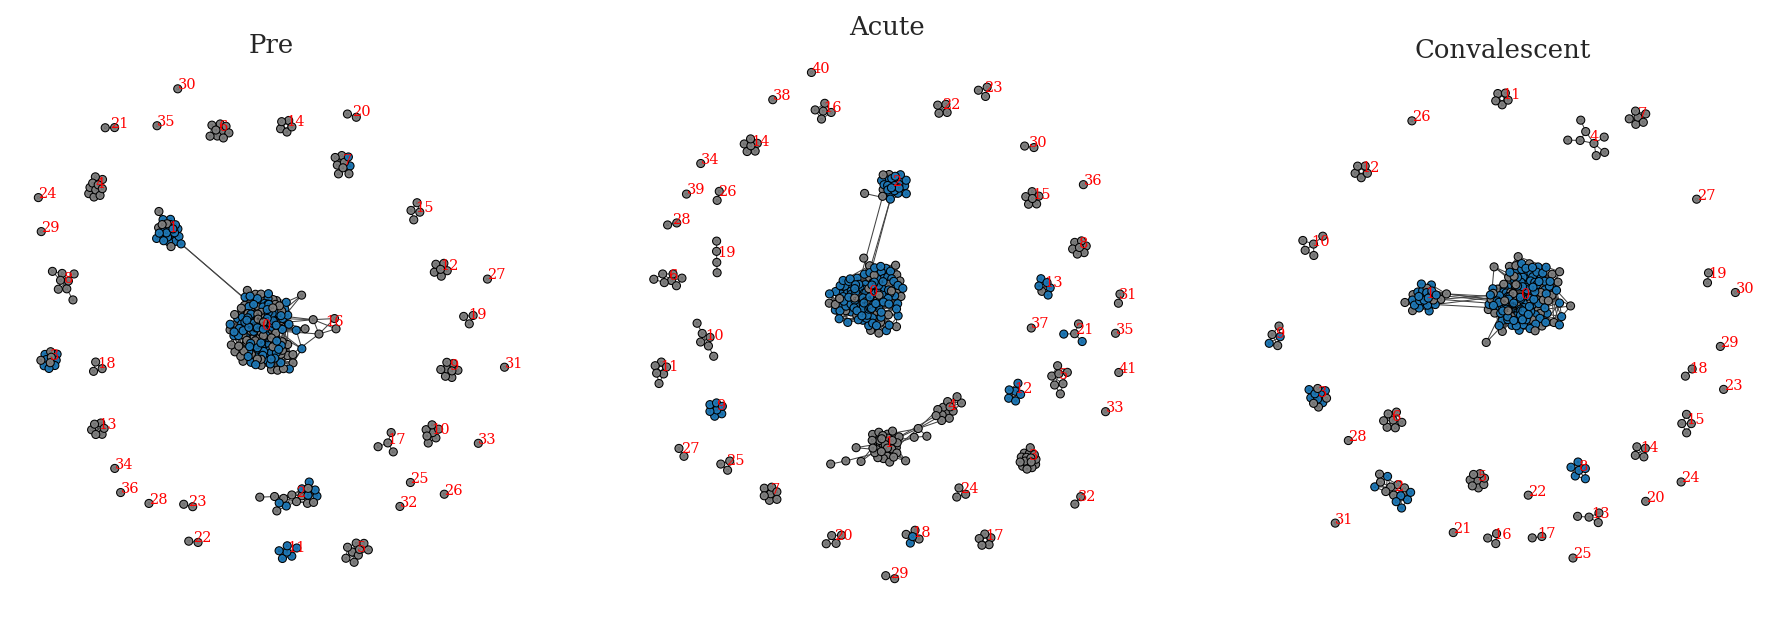

In [26]:
def annotate_network(res, persistent, ax=None, size=True):

        layout = res.Gi.layout("graphopt", niter=1000)

        node_data = res.data.iloc[[i['_nx_name'] for i in res.Gi.vs]]
        node_data['color'] = node_data.full_clone.apply(lambda x: 'tab:blue' if x in persistent else 'tab:grey')

        x = [i[0] for i in layout]
        y = [i[1] for i in layout]

        visual_style = {'edge_width': 0.5,}
        ig.plot(res.Gi,
                layout=layout,
                **visual_style,
                target=ax)

        c = node_data['color']
        if size:
                s = -np.log10(node_data.evalue) * 2
        else:
                s = 15
        ax.scatter(x, y, c=c, cmap='viridis', s=s, edgecolors='black', linewidths=0.5)

        return c, layout

def add_cluster_labels(res, layout, ax):

        x = [i[0] for i in layout]
        y = [i[1] for i in layout]

        node_data = res.data.iloc[[i['_nx_name'] for i in res.Gi.vs]]

        node_data['x_coord'] = x
        node_data['y_coord'] = y

        for clus in node_data.cluster.unique():
                cluster = node_data[node_data.cluster==clus]
                ax.text(
                        x=cluster.x_coord.mean(), 
                        y=cluster.y_coord.mean(),
                        s=str(clus),
                        c='red',
                        fontsize=7
                )

# Cluster SNE clones
res_pre.get_clusters(100, resolution=1e-2)
res_acute.get_clusters(100, resolution=1e-2)
res_conv.get_clusters(100, resolution=1e-2)

# Select SNE clones
sign_pre = res_pre.data[res_pre.data['evalue']<.05]
sign_acute = res_acute.data[res_acute.data['evalue']<.05]
sign_conv = res_conv.data[res_conv.data['evalue']<.05]

clonecols = ['cdr3b_nucseq','vb','jb','cdr3b','cdr3a_nucseq','va','ja','cdr3a']
sign_pre['full_clone'] = sign_pre.apply(lambda x: '_'.join([str(x[i]) for i in clonecols]), axis=1)
sign_acute['full_clone'] = sign_acute.apply(lambda x: '_'.join([str(x[i]) for i in clonecols]), axis=1)
sign_conv['full_clone'] = sign_conv.apply(lambda x: '_'.join([str(x[i]) for i in clonecols]), axis=1)
res_pre.data['full_clone'] = res_pre.data.apply(lambda x: '_'.join([str(x[i]) for i in clonecols]), axis=1)
res_acute.data['full_clone'] = res_acute.data.apply(lambda x: '_'.join([str(x[i]) for i in clonecols]), axis=1)
res_conv.data['full_clone'] = res_conv.data.apply(lambda x: '_'.join([str(x[i]) for i in clonecols]), axis=1)

persistent = set(sign_pre.full_clone).intersection(set(sign_acute.full_clone)).intersection(set(sign_conv.full_clone))

fig, ax = plt.subplots(dpi=150, figsize=(15,5), ncols=3)

c1, layout1 = annotate_network(res_pre, persistent, ax=ax[0], size=False)
c2, layout2 = annotate_network(res_acute, persistent, ax=ax[1], size=False)
c3, layout3 = annotate_network(res_conv, persistent, ax=ax[2], size=False)

add_cluster_labels(res_pre, layout1, ax[0])
add_cluster_labels(res_acute, layout2, ax[1])
add_cluster_labels(res_conv, layout3, ax[2])

ax[0].set_title('Pre')
ax[1].set_title('Acute')
ax[2].set_title('Convalescent')

fig.savefig('../sne_manuscript/manuscript_figures/tirtl_sne_network_cd8_persistent.svg', bbox_inches='tight', format='svg')

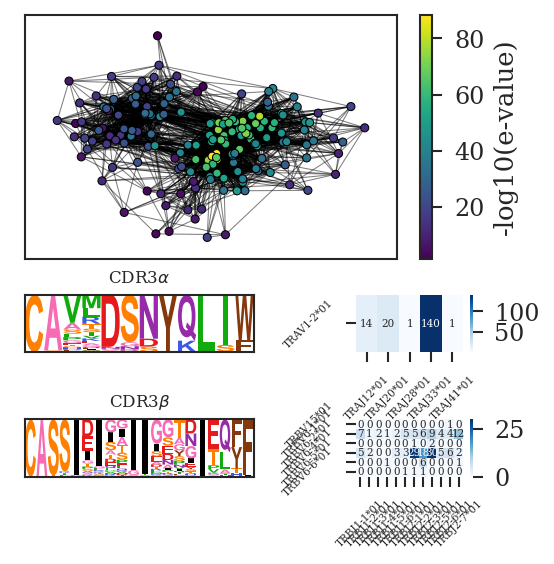

In [27]:
fig = res_acute.draw_cluster(0)

fig.savefig('../sne_manuscript/manuscript_figures/tirtl_sne_cluster_0_cd8_persistent.svg', bbox_inches='tight', format='svg')

In [28]:
print(len(persistent) / pre.shape[0])
print(len(persistent) / acute.shape[0])
print(len(persistent) / conv.shape[0])

print(len(persistent) / sign_pre.shape[0])
print(len(persistent) / sign_acute.shape[0])
print(len(persistent) / sign_conv.shape[0])

0.01858356940509915
0.01761168384879725
0.020093114432737074
0.40097799511002447
0.4
0.5061728395061729


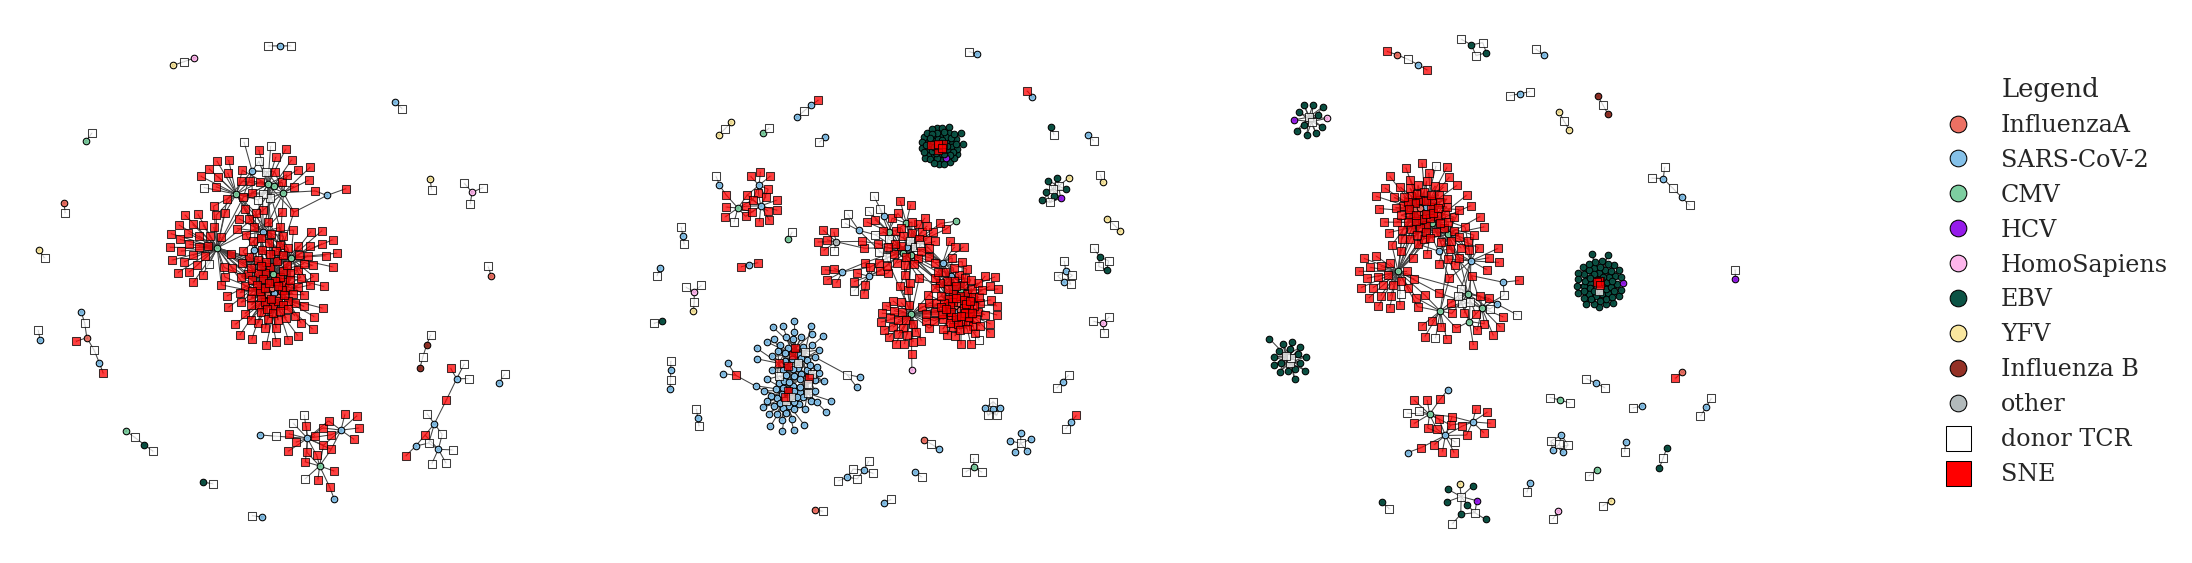

In [29]:
fig, ax = plt.subplots(figsize=(15,5), dpi=150, ncols=3)

nodes_pre, edges_pre, annotated_pre = vdjdb_annotation_network(res_pre.data, vdjdb_paired, fig=fig, ax=ax[0], cutoff=.05, annotate=True)
nodes_acute, edges_acute, annotated_acute = vdjdb_annotation_network(res_acute.data, vdjdb_paired, fig=fig, ax=ax[1], cutoff=.05, annotate=True)
nodes_conv, edges_conv, annotated_conv = vdjdb_annotation_network(res_conv.data, vdjdb_paired, fig=fig, ax=ax[2], legend=True, cutoff=.05, annotate=True)

In [25]:
node_to_species = {i:vdjdb_paired.loc[int(i.split('_')[0])]['antigen.species'] for i in nodes_acute if 'VDJDB' in i}
node_to_epitope = {i:vdjdb_paired.loc[int(i.split('_')[0])]['antigen.epitope'] for i in nodes_acute if 'VDJDB' in i}

sne_species = {}
for i in edges_acute:
    tcr_index = int(i[0].split('_')[0])
    if tcr_index not in sne_species:
        sne_species[tcr_index] = {node_to_species[i[1]]}
    else:
        sne_species[tcr_index].add(node_to_species[i[1]])

sne_epitope = {}
for i in edges_acute:
    tcr_index = int(i[0].split('_')[0])
    if tcr_index not in sne_epitope:
        sne_epitope[tcr_index] = {node_to_epitope[i[1]]}
    else:
        sne_epitope[tcr_index].add(node_to_epitope[i[1]])

mapped_species = [sne_species[x] if x in sne_species else None for x in res_acute.data.index]
mapped_epitope = [sne_epitope[x] if x in sne_epitope else None for x in res_acute.data.index]
res_acute.data['mapped_species'] = mapped_species
res_acute.data['mapped_epitope'] = mapped_epitope

NameError: name 'nodes_acute' is not defined

In [43]:
res_acute.data[res_acute.data.mapped_species == {'EBV','HCV'}].mapped_epitope.value_counts()

{CINGVCWTV, GLCTLVAML}    8
Name: mapped_epitope, dtype: int64

In [44]:
res_acute.data[res_acute.data.mapped_species == {'EBV','HCV'}]

# res_acute.data[res_acute.data.mapped_species == {'SARS-CoV-2'}].cluster.value_counts()

res_acute.data[res_acute.data.cluster == 4]
res_acute.draw_cluster(4)

,pvalue,evalue,tcr_index,radius,num_nbrs,expected_num_nbrs,bg_nbrs,timepoint,wi,wj,...,va,ja,cdr3b,vb,jb,is_mait,cluster,full_clone,mapped_species,mapped_epitope
279,2.946741e-01,2635.565260,3734,100,2,1.082816,968276.0,cd8_acute,0,1,...,TRAV5*01,TRAJ34*01,CASSVVGNEQFF,TRBV9*01,TRBJ2-1*01,False,-1,tgtgccagcagcgtagtggggaatgagcagttcttc_TRBV9*01_...,"{EBV, HCV}","{CINGVCWTV, GLCTLVAML}"
307,1.447192e-01,1294.368580,4164,100,2,0.667877,597229.0,cd8_acute,0,3,...,TRAV5*01,TRAJ11*01,CASSVAGNEQFF,TRBV9*01,TRBJ2-1*01,False,-1,tgtgccagcagcgtagctgggaatgagcagttcttc_TRBV9*01_...,"{EBV, HCV}","{CINGVCWTV, GLCTLVAML}"
405,1.748000e-07,0.001563,5504,100,6,0.231368,206894.0,cd8_acute,1,8,...,TRAV5*01,TRAJ31*01,CSARDRVGNTIYF,TRBV20-1*01,TRBJ1-3*01,False,6,tgcagtgctagagatcgggtgggaaacaccatatatttt_TRBV20...,"{EBV, HCV}","{CINGVCWTV, GLCTLVAML}"
452,1.827593e-07,0.001635,6269,100,6,0.233151,208488.0,cd8_acute,2,18,...,TRAV5*01,TRAJ31*01,CSARDRVGNTIYF,TRBV20-1*01,TRBJ1-3*01,False,6,tgcagtgctcgagacagagttggaaacaccatatatttt_TRBV20...,"{EBV, HCV}","{CINGVCWTV, GLCTLVAML}"
533,3.469455e-06,0.031031,7046,100,6,0.389346,348161.0,cd8_acute,4,27,...,TRAV5*01,TRAJ31*01,CSARDRTGNGYTF,TRBV20-1*01,TRBJ1-2*01,False,6,tgcagtgctagagaccggacaggaaatggctacaccttc_TRBV20...,"{EBV, HCV}","{CINGVCWTV, GLCTLVAML}"
548,2.812673e-07,0.002516,7229,100,7,0.412482,368850.0,cd8_acute,5,11,...,TRAV5*01,TRAJ31*01,CSARDGTGNGYTF,TRBV20-1*01,TRBJ1-2*01,False,6,tgcagtgctagagatgggacagggaatggctacaccttc_TRBV20...,"{EBV, HCV}","{CINGVCWTV, GLCTLVAML}"
573,1.827593e-07,0.001635,7494,100,6,0.233151,208488.0,cd8_acute,6,16,...,TRAV5*01,TRAJ31*01,CSARDRVGNTIYF,TRBV20-1*01,TRBJ1-3*01,False,6,tgcagtgctcgggacagggttggaaacaccatatatttt_TRBV20...,"{EBV, HCV}","{CINGVCWTV, GLCTLVAML}"
730,3.292275e-08,0.000294,8905,100,6,0.173740,155362.0,cd8_acute,37,0,...,TRAV5*01,TRAJ31*01,CSARDRVENTIYF,TRBV20-1*01,TRBJ1-3*01,False,6,tgcagtgctagagatcgggtggaaaacaccatatatttt_TRBV20...,"{EBV, HCV}","{CINGVCWTV, GLCTLVAML}"


In [32]:
fig.savefig('../sne_manuscript/manuscript_figures/tirtl_sne_network_cd8_annotated.svg', bbox_inches='tight', format='svg')

And binary -- applying a hard significance cutoff at E < .05

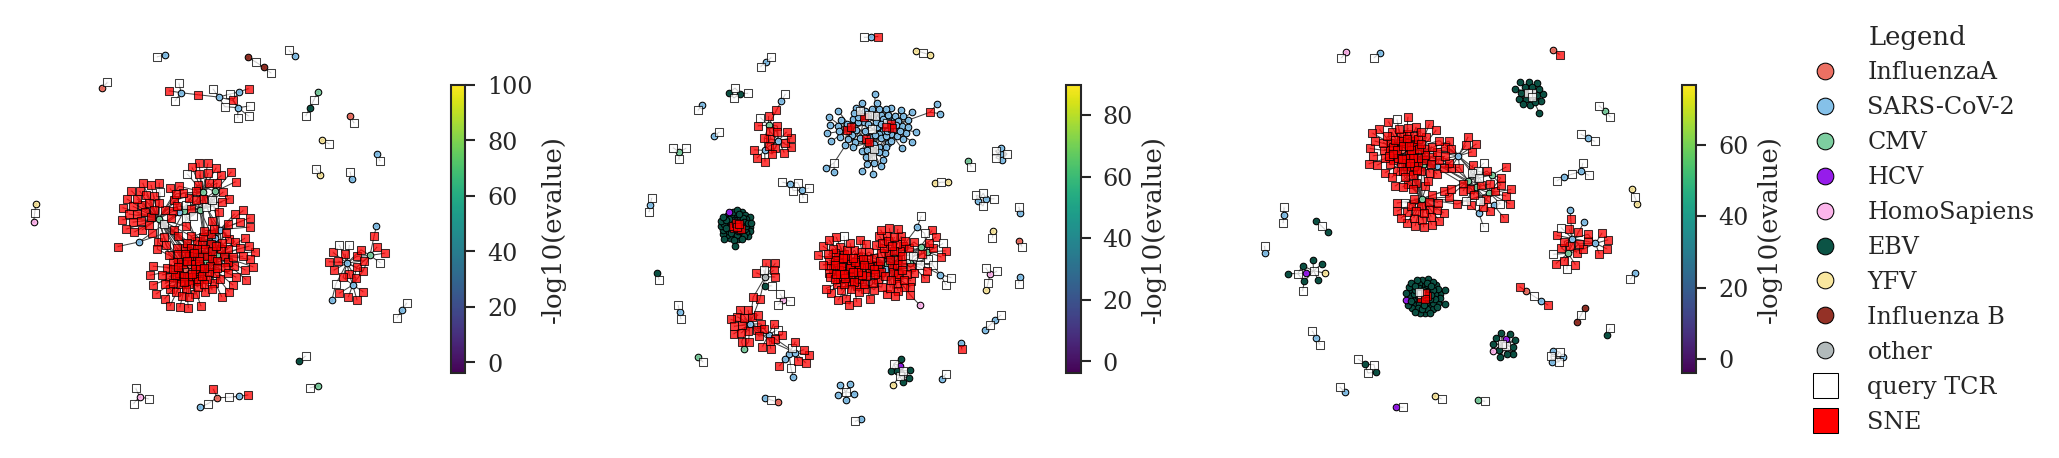

In [205]:
fig, ax = plt.subplots(figsize=(15,5), dpi=150, ncols=3)

_ = vdjdb_annotation_network(res_pre.data, vdjdb_paired, fig=fig, ax=ax[0], cutoff=.05, annotate=True)
_ = vdjdb_annotation_network(res_acute.data, vdjdb_paired, fig=fig, ax=ax[1], cutoff=.05, annotate=True)
_ = vdjdb_annotation_network(res_conv.data, vdjdb_paired, fig=fig, ax=ax[2], cutoff=.05, annotate=True, legend=True)

Zooming in on the significant clones (SNE)

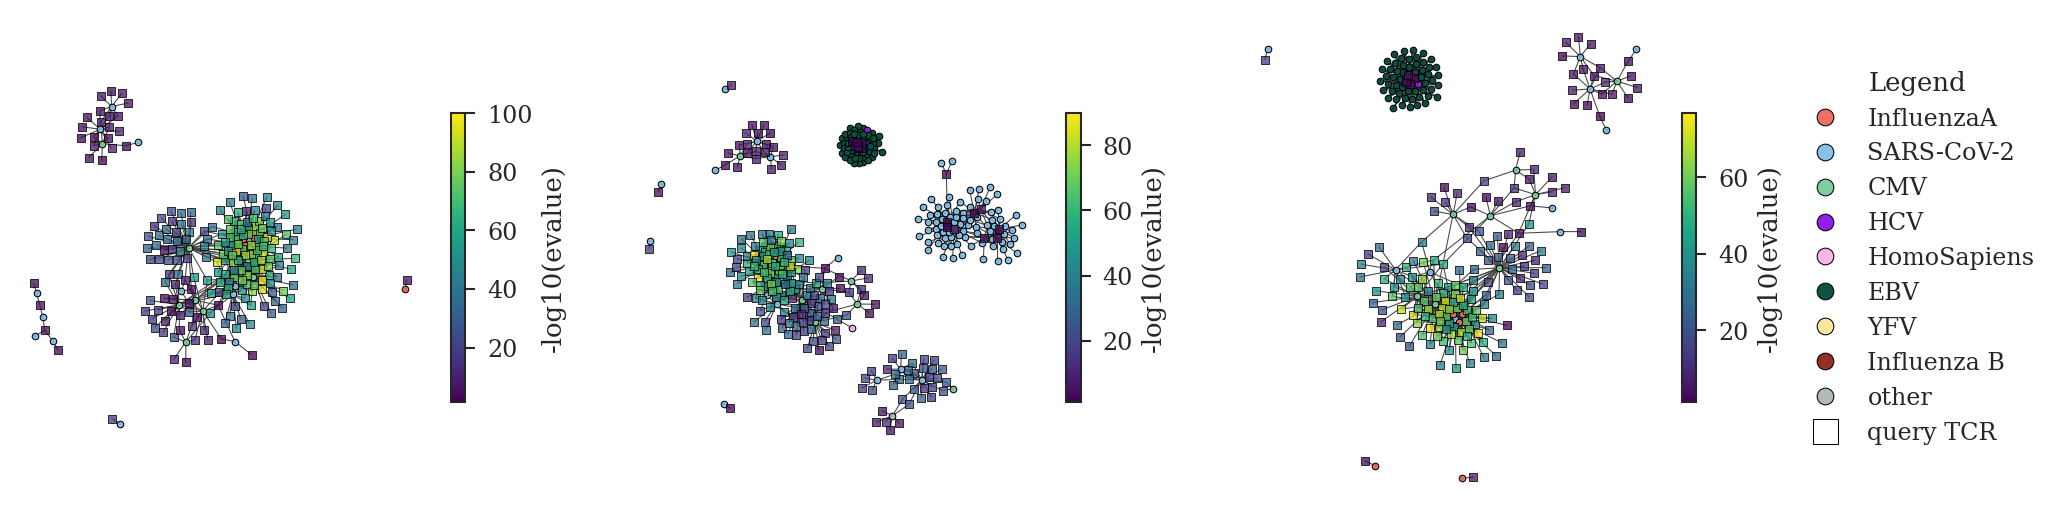

In [208]:
fig, ax = plt.subplots(figsize=(15,5), dpi=150, ncols=3)

_ = vdjdb_annotation_network(res_pre.data[res_pre.data.evalue<.05].reset_index(drop=True), vdjdb_paired, fig=fig, ax=ax[0], annotate=True)
_ = vdjdb_annotation_network(res_acute.data[res_acute.data.evalue<.05].reset_index(drop=True), vdjdb_paired, fig=fig, ax=ax[1], annotate=True)
_ = vdjdb_annotation_network(res_conv.data[res_conv.data.evalue<.05].reset_index(drop=True), vdjdb_paired, fig=fig, ax=ax[2], annotate=True, legend=True)

### Adding abundance info -- looking at expanded clones at the acute timepoint

Co-cluster SNE clones with paired VDJdb TCRs to identify specificity clusters.

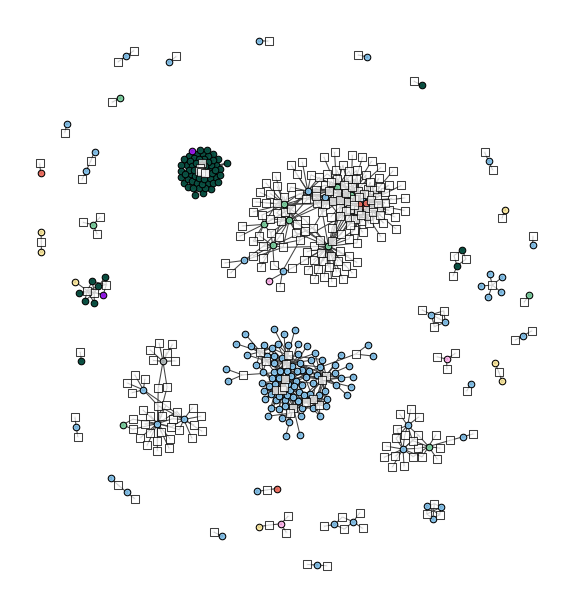

In [38]:
fig, ax = plt.subplots(figsize=(5,5), dpi=150)
nodes_cd8_acute, edges_cd8_acute = vdjdb_annotation_network(res_acute.data, vdjdb_paired, fig=fig, ax=ax)

Map the epitopes and species to the SNE clones

In [39]:
node_to_species = {i:vdjdb_paired.loc[int(i.split('_')[0])]['antigen.species'] for i in nodes_cd8_acute if 'VDJDB' in i}
node_to_epitope = {i:vdjdb_paired.loc[int(i.split('_')[0])]['antigen.epitope'] for i in nodes_cd8_acute if 'VDJDB' in i}

sne_species = {}
for i in edges_cd8_acute:
    tcr_index = int(i[0].split('_')[0])
    if tcr_index not in sne_species:
        sne_species[tcr_index] = {node_to_species[i[1]]}
    else:
        sne_species[tcr_index].add(node_to_species[i[1]])

sne_epitope = {}
for i in edges_cd8_acute:
    tcr_index = int(i[0].split('_')[0])
    if tcr_index not in sne_epitope:
        sne_epitope[tcr_index] = {node_to_epitope[i[1]]}
    else:
        sne_epitope[tcr_index].add(node_to_epitope[i[1]])

mapped_species = [sne_species[x] if x in sne_species else None for x in res_acute.data.index]
mapped_epitope = [sne_epitope[x] if x in sne_epitope else None for x in res_acute.data.index]
res_acute.data['mapped_species'] = mapped_species
res_acute.data['mapped_epitope'] = mapped_epitope
res_acute.data.head()

,pvalue,evalue,tcr_index,radius,num_nbrs,expected_num_nbrs,bg_nbrs,timepoint,wi,wj,...,cdr3a,va,ja,cdr3b,vb,jb,is_mait,cluster,mapped_species,mapped_epitope
0,1.030787e-04,9.598689e-01,1,100,3,0.087071,81063.0,cd8_acute,0,0,...,CALQGNNNARLMF,TRAV21*01,TRAJ31*01,CASSLAGVHRTTDTQYF,TRBV5-1*01,TRBJ2-3*01,False,-1,None,None
1,5.303185e-13,4.938326e-09,5,100,7,0.060054,55910.0,cd8_acute,0,0,...,CALSEVIRAGTALIF,TRAV19*01,TRAJ15*01,CASSSLLAGGFYEQYF,TRBV27*01,TRBJ2-7*01,False,7,None,None
2,9.196891e-04,8.564144e+00,9,100,2,0.043513,40511.0,cd8_acute,0,0,...,CATVGNSGYSTLTF,TRAV17*01,TRAJ11*01,CASSPLGGNYGYTF,TRBV6-5*01,TRBJ1-2*01,False,-1,{EBV},{FLYALALLL}
3,1.662992e-07,1.548578e-03,13,100,5,0.117078,109000.0,cd8_acute,0,0,...,CAVTRSQGNLIF,TRAV12-2*01,TRAJ42*01,CASSYYRGGNQPQHF,TRBV28*01,TRBJ1-5*01,False,32,None,None
4,1.999339e-03,1.861785e+01,18,100,2,0.064608,60150.0,cd8_acute,0,0,...,CAVNSGNQFYF,TRAV12-2*01,TRAJ49*01,CASSPVAGGPRGELLF,TRBV6-6*01,TRBJ2-2*01,False,-1,None,None


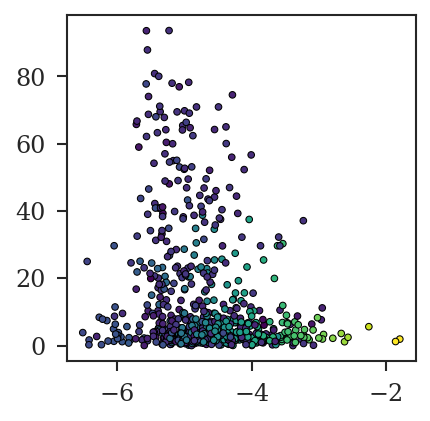

In [45]:
longi_cd8 = pd.read_table('./data/cd8_tp1_tp2_longitudinal_beta.tsv')
longi_cd8['nSeqCDR3'] = longi_cd8['nSeqCDR3'].str.lower()

longi_data_cd8 = longi_cd8[['nSeqCDR3','avg.y','log2FC']].merge(acute, left_on='nSeqCDR3', right_on='cdr3b_nucseq')
commoncols = set(longi_data_cd8.columns).intersection(res_acute.data.columns)

merged_all_cd8 = longi_data_cd8.merge(res_acute.data, on=list(commoncols), how='left')
merged_res_cd8 = longi_data_cd8.merge(res_acute.data, on=list(commoncols), how='inner')
# merged_all['pvalue'] = merged_all.pvalue.fillna(1)

merged_all_cd8['log10pval'] = -np.log10(merged_all_cd8.pvalue)
merged_res_cd8['log10pval'] = -np.log10(merged_res_cd8.pvalue)

fig, ax = plt.subplots(dpi=150, figsize=(3,3))

x = np.log10(merged_all_cd8['avg.y'])
y = -np.log10(merged_all_cd8['pvalue'])
c = merged_all_cd8['log2FC']

ax.scatter(x, y, c=c, cmap='viridis', s=10, edgecolors='black', linewidths=0.5)

In [51]:
longi_cd8 = pd.read_table('./data/cd8_tp1_tp2_longitudinal_beta.tsv')
longi_cd8['nSeqCDR3'] = longi_cd8['nSeqCDR3'].str.lower()

longi_cd8

,nSeqCDR3,avg.x,sem.x,wells.x,avg_well.x,avg.y,sem.y,wells.y,avg_well.y,log2FC,sign
0,cacagcgccgggacaccttatggctacaccttc,0.000000e+00,5.692385e-06,0,0.000000,9.172113e-08,3.850184e-08,6,0.000003,0.126604,stable
1,cccgagcggcgagagatcgggttagagcagtacttc,0.000000e+00,5.692385e-06,0,0.000000,1.960778e-06,5.325665e-07,17,0.000022,1.565976,stable
2,ccctactcacggggcttacactgaagctttcttt,2.592147e-06,8.155221e-07,11,0.000045,6.551083e-07,2.714025e-07,6,0.000021,-1.117921,stable
3,cgcagcagaggcgcagatacgcagtatttt,1.873447e-07,9.325517e-08,5,0.000007,5.836763e-08,2.196198e-06,1,0.000011,-0.165898,stable
4,cgcagcgccggagggaacactgaagctttcttt,0.000000e+00,5.692385e-06,0,0.000000,4.522921e-07,2.003285e-07,6,0.000014,0.538332,stable
...,...,...,...,...,...,...,...,...,...,...,...
44287,ttgtgctagtggttcttggacaggcaatgagcagttcttc,1.420529e-06,3.981132e-07,16,0.000017,8.223912e-07,2.226493e-07,15,0.000011,-0.409490,stable
44288,ttgtgctagtggtttgataggtcaaaacccaaatgagcagttcttc,0.000000e+00,5.692385e-06,0,0.000000,3.092619e-07,1.468099e-07,5,0.000012,0.388754,stable
44289,ttgtgctagtggtttggtgactagcgggagggcggacaccggggag...,0.000000e+00,5.692385e-06,0,0.000000,1.305275e-06,2.969362e-07,25,0.000010,1.204939,stable
44290,tttgccagtagtgttggcagaactggctacaccttc,0.000000e+00,5.692385e-06,0,0.000000,3.686478e-06,1.004840e-06,13,0.000054,2.228504,stable


In [60]:
expanded = False

longi_cd8 = pd.read_table('./data/cd8_tp1_tp2_longitudinal_beta.tsv')
longi_cd8['nSeqCDR3'] = longi_cd8['nSeqCDR3'].str.lower()

longi_data_cd8 = longi_cd8[['nSeqCDR3','avg.y','log2FC']].merge(acute, left_on='nSeqCDR3', right_on='cdr3b_nucseq')
if expanded:
    cd8_expanded = longi_data_cd8[longi_data_cd8.log2FC>3].reset_index(drop=True)
else:
    cd8_expanded = longi_data_cd8.reset_index(drop=True)

res_cd8_exp = neighbor_analysis(cd8_expanded,'AB','human',100)
res_cd8_exp.get_clusters(100, resolution=1e-2)
res_cd8_exp_sign = res_cd8_exp.data[res_cd8_exp.data['evalue']<.05]

Encoding TCRs
Computing neighbor distribution for 6369 TCRs in sample.
Neighbor distribution calculation took 0.95s
Creating background data set with 63690 TCRs
No AIRR format detected, proceeding with paired TCRdist format.
Estimating expected neighbor distribution with the following parameters: dims = 296; maxdist = 100.
paired distribution calc took 7.21
Encoding TCRs took 0.03s
Building the index took 0.00s
Searching index within radius 100 took 0.06s
Building the sparse matrix took 0.04s
Total time to compute distance matrix: 0.29s


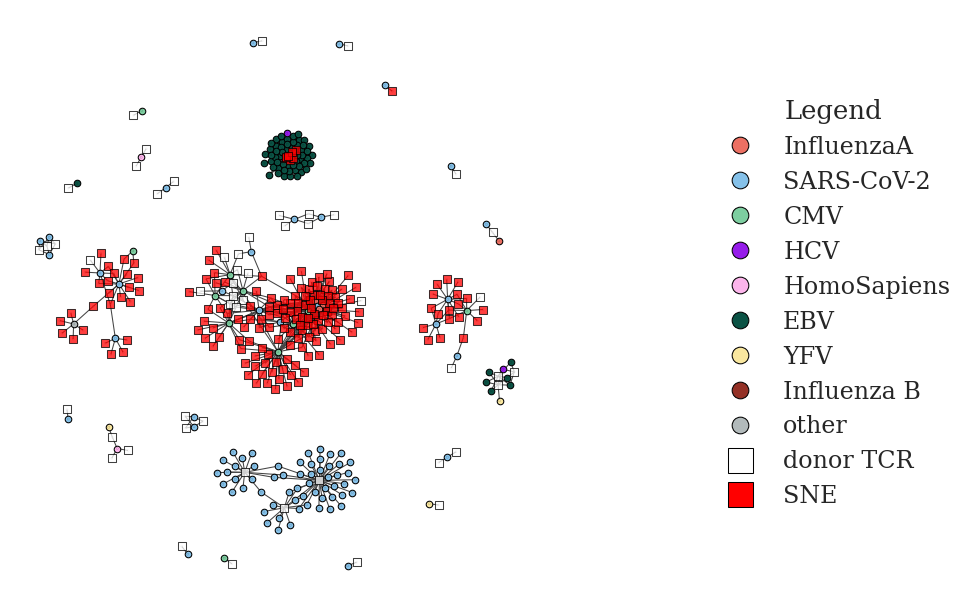

In [61]:
fig, ax = plt.subplots(figsize=(5,5), dpi=150)
nodes_cd8_exp, edges_cd8_exp = vdjdb_annotation_network(res_cd8_exp.data, vdjdb_paired, fig, ax, legend=True, cutoff=0.05, annotate=True)

def add_annotation(data, nodes, edges):

    node_to_species = {i:vdjdb_paired.loc[int(i.split('_')[0])]['antigen.species'] for i in nodes if 'VDJDB' in i}
    node_to_epitope = {i:vdjdb_paired.loc[int(i.split('_')[0])]['antigen.epitope'] for i in nodes if 'VDJDB' in i}

    sne_species = {}
    for i in edges:
        tcr_index = int(i[0].split('_')[0])
        if tcr_index not in sne_species:
            sne_species[tcr_index] = {node_to_species[i[1]]}
        else:
            sne_species[tcr_index].add(node_to_species[i[1]])

    sne_epitope = {}
    for i in edges:
        tcr_index = int(i[0].split('_')[0])
        if tcr_index not in sne_epitope:
            sne_epitope[tcr_index] = {node_to_epitope[i[1]]}
        else:
            sne_epitope[tcr_index].add(node_to_epitope[i[1]])

    mapped_species = [sne_species[x] if x in sne_species else None for x in data.index]
    mapped_epitope = [sne_epitope[x] if x in sne_epitope else None for x in data.index]
    data['mapped_species'] = mapped_species
    data['mapped_epitope'] = mapped_epitope

    return data

final = add_annotation(res_cd8_exp.data, nodes_cd8_exp, edges_cd8_exp)

NameError: name 'final' is not defined

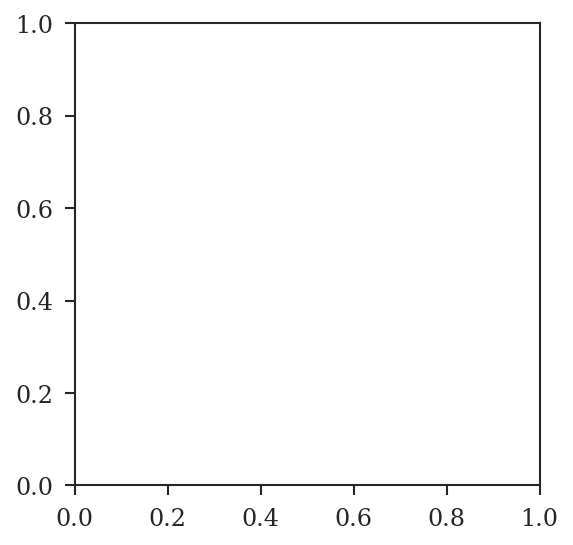

In [23]:
import matplotlib.lines as mlines

fig, ax = plt.subplots(dpi=150, figsize=(4,4))

ax.scatter(
    x=final.log2FC,
    y=-np.log10(final.pvalue),
    c='grey',
    s=15,
)

# Define the conditions for identifying MAIT cells
mait_va = 'TRAV1-2*01'
mait_ja = {'TRAJ33*01', 'TRAJ12*01', 'TRAJ20*01'}

# Update 'mapped_species' column to tag MAIT cells
final['mapped_species_mait'] = final.apply(
    lambda row: 'MAIT' if (row['va'] == mait_va and row['ja'] in mait_ja) else row['mapped_species'],
    axis=1
)

def ebv_sarscov_annotation(annot):
    if annot is None:
        return None
    elif 'EBV' in annot:
        return 'EBV'
    elif 'SARS-CoV-2' in annot:
        return 'SARS-CoV-2'
    elif annot == 'MAIT':
        return 'MAIT'
    elif len(annot) > 0:
        return 'other'

final['mapped_species_mait'] = final.mapped_species_mait.apply(ebv_sarscov_annotation)

annotation_color = {
    'MAIT': 'tab:red',
    'SARS-CoV-2': 'tab:blue',
    'other': 'tab:orange',
    'EBV': 'tab:green',
}

final['annotation_color'] = final.mapped_species_mait.map(annotation_color)
annot_only = final.dropna(subset=['annotation_color'])

ax.scatter(
    x=annot_only.log2FC,
    y=-np.log10(annot_only.pvalue),
    c=annot_only.annotation_color,
    s=15,
    edgecolors='black',
    linewidths=0.5
)

leg_color = {
    'TRAV1-2\nTRAJ33/20/12\n(MAIT)': 'tab:red',
    'SARS-CoV-2': 'tab:blue',
    'EBV': 'tab:green',
    'other': 'tab:orange',
}

# Create custom legend elements
legend_elements = [
    mlines.Line2D([], [], color=color, marker='o', markersize=8, markeredgewidth=0.5, markeredgecolor='black', linestyle='None', label=label)
    for label, color in leg_color.items()
]

# Add dashed and dotted lines to the legend
legend_elements += [
    mlines.Line2D([], [], color='black', linestyle='dashed', linewidth=1, label='enrichment threshold'),
    mlines.Line2D([], [], color='black', linestyle='dotted', linewidth=1, label='expansion threshold')
]

ax.set_xlabel('log2FC')
ax.set_ylabel('-log10(p-value)')
ax.legend(handles=legend_elements, loc='upper right', frameon=False, fontsize=8)
ax.axhline(-np.log10(0.000020), color='black', linestyle='dashed', linewidth=1, zorder=0)
ax.axvline(3, color='black', linestyle='dotted', linewidth=1, zorder=0)

fig.suptitle('CD8 - acute')
fig.tight_layout()
# fig.savefig('../sne_manuscript/manuscript_figures/tirtl_sne_expansion_cd8_acute.svg', bbox_inches='tight', format='svg')

NameError: name 'merged_all' is not defined

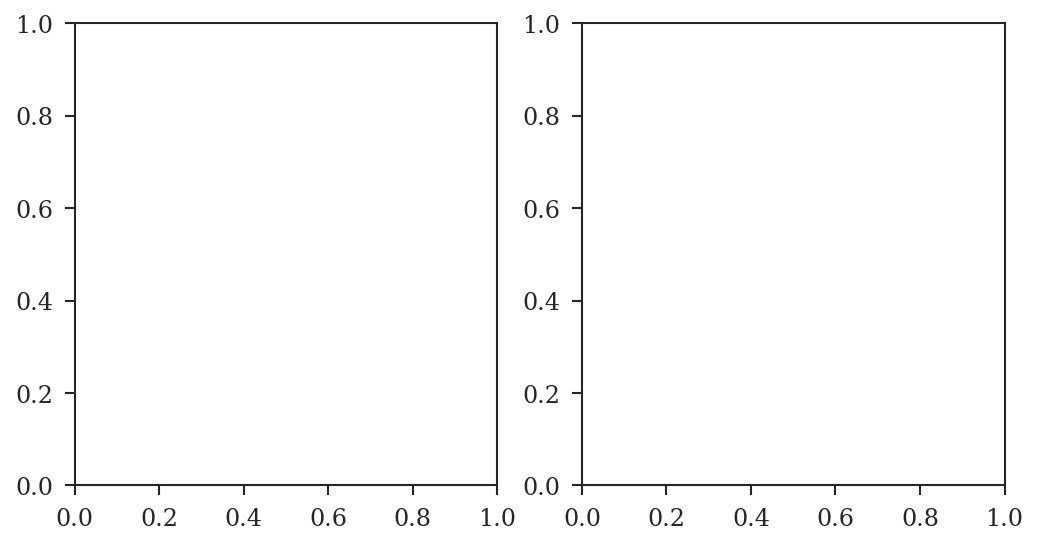

In [56]:
fig, ax = plt.subplots(dpi=150, figsize=(8,4), ncols=2)

sns.kdeplot(merged_all.log10pval, ax=ax[0], shade=True, shade_lowest=False, label='All clones')
sns.kdeplot(merged_all[merged_all.log2FC>3].log10pval, ax=ax[0], shade=True, shade_lowest=False, label='Expanded')

ax[0].set_xlim(-10,100)
# ax[0].set_title('CD8 - acute')

ax[0].legend()

ax[1].scatter(
    x = merged_res.log2FC,
    y = merged_res.log10pval,
    c = 'grey',
    s = 15,
    # edgecolors='black',
    # linewidths=0.5
)

# Define the conditions for identifying MAIT cells
mait_va = 'TRAV1-2*01'
mait_ja = {'TRAJ33*01', 'TRAJ12*01', 'TRAJ20*01'}

# Update 'mapped_species' column to tag MAIT cells
merged_res['mapped_species_mait'] = merged_res.apply(
    lambda row: 'MAIT' if (row['va'] == mait_va and row['ja'] in mait_ja) else row['mapped_species'],
    axis=1
)

def ebv_sarscov_annotation(annot):
    if annot is None:
        None
    elif 'EBV' in annot:
        return 'EBV'
    elif 'SARS-CoV-2' in annot:
        return 'SARS-CoV-2'
    elif annot == 'MAIT':
        return 'MAIT'
    elif len(annot) > 0:
        return 'other'

merged_res['mapped_species_mait'] = merged_res.mapped_species_mait.apply(ebv_sarscov_annotation)

annotation_color = {
    'MAIT':'tab:red',
    'SARS-CoV-2':'tab:blue',
    'other':'tab:orange',
    'EBV':'tab:green',
}

merged_res['annotation_color'] = merged_res.mapped_species_mait.map(annotation_color)
annot_only = merged_res.dropna(subset=['annotation_color'])

ax[1].scatter(
    x = annot_only.log2FC,
    y = annot_only.log10pval,
    c = annot_only.annotation_color,
    s = 15,
    edgecolors='black',
    linewidths=0.5
)

ax[1].axvline(x=3, color='black', linestyle='--', linewidth=1, zorder=0)

leg_color = {
    'TRAV1-2\nTRAJ33/20/12\n(MAIT)':'tab:red',
    'SARS-CoV-2':'tab:blue',
    'EBV':'tab:green',
    'other':'tab:orange',
}

# Create custom legend elements
legend_elements = [
    mlines.Line2D([], [], color=color, marker='o', markersize=8, markeredgewidth=0.5, markeredgecolor='black', linestyle='None', label=label)
    for label, color in leg_color.items()
]

ax[1].set_xlabel('log2FC')
ax[1].set_ylabel('-log10(p-value)')
ax[1].text(x=3.5, y=45, s='Expanded clones', fontsize=8, color='black')
ax[1].legend(handles=legend_elements, loc='upper right', frameon=False, fontsize=8)

fig.suptitle('CD8 - acute')
fig.tight_layout()

# merged_all

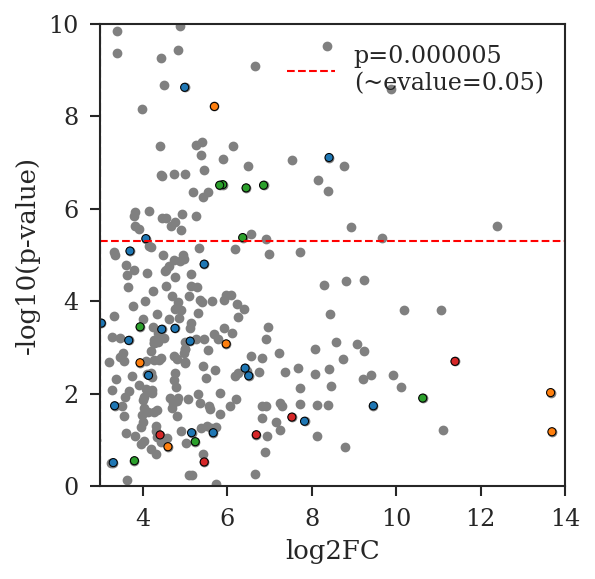

In [199]:
fig, ax = plt.subplots(dpi=150, figsize=(4,4))

ax.scatter(
    x = merged_res.log2FC,
    y = merged_res.log10pval,
    c = 'grey',
    s = 15,
    # edgecolors='black',
    # linewidths=0.5
)

ax.scatter(
    x = annot_only.log2FC,
    y = annot_only.log10pval,
    c = annot_only.annotation_color,
    s = 15,
    edgecolors='black',
    linewidths=0.5
)

ax.axvline(x=3, color='black', linestyle='--', linewidth=1)

leg_color = {
    'TRAV1-2;TRAJ33/20/12 (MAIT)':'tab:red',
    'SARS-CoV-2':'tab:blue',
    'other':'tab:orange',
    'EBV':'tab:green',
}

# Create custom legend elements
legend_elements = [
    mlines.Line2D([], [], color=color, marker='o', markersize=8, markeredgewidth=0.5, markeredgecolor='black', linestyle='None', label=label)
    for label, color in leg_color.items()
]

ax.set_xlim(3,14)
ax.set_ylim(0,-np.log10(1e-10))

ax.axhline(-np.log10(0.000005), ls='--', label='p=0.000005\n(~evalue=0.05)', color='red', linewidth=1)

ax.set_xlabel('log2FC')
ax.set_ylabel('-log10(p-value)')

ax.legend()
# ax.text(x=3.5, y=70, s='Expanded clones', fontsize=8, color='black')
# ax.legend(handles=legend_elements, bbox_to_anchor=(1.05,0.5), loc='center left', frameon=False, title="Annotation", fontsize=8)

# fig.suptitle('CD8 - acute')

/tmp/ipykernel_1337942/4210920438.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x = annot_only[merged_res.mapped_species_mait!='MAIT'].log2FC,
/tmp/ipykernel_1337942/4210920438.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  y = annot_only[merged_res.mapped_species_mait!='MAIT'].log10pval,
/tmp/ipykernel_1337942/4210920438.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  c = annot_only[merged_res.mapped_species_mait!='MAIT'].annotation_color,


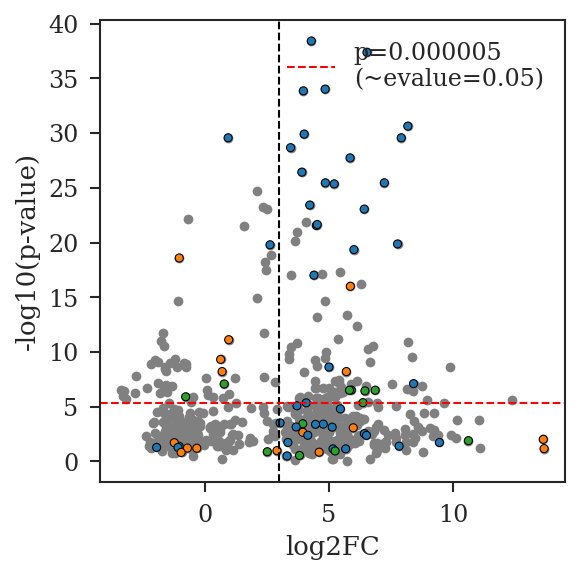

In [202]:
fig, ax = plt.subplots(dpi=150, figsize=(4,4))

ax.scatter(
    x = merged_res[merged_res.mapped_species_mait!='MAIT'].log2FC[merged_res.mapped_species_mait!='MAIT'],
    y = merged_res[merged_res.mapped_species_mait!='MAIT'].log10pval,
    c = 'grey',
    s = 15,
    # edgecolors='black',
    # linewidths=0.5
)

ax.scatter(
    x = annot_only[merged_res.mapped_species_mait!='MAIT'].log2FC,
    y = annot_only[merged_res.mapped_species_mait!='MAIT'].log10pval,
    c = annot_only[merged_res.mapped_species_mait!='MAIT'].annotation_color,
    s = 15,
    edgecolors='black',
    linewidths=0.5
)

ax.axvline(x=3, color='black', linestyle='--', linewidth=1)

leg_color = {
    'TRAV1-2;TRAJ33/20/12 (MAIT)':'tab:red',
    'SARS-CoV-2':'tab:blue',
    'other':'tab:orange',
    'EBV':'tab:green',
}

# Create custom legend elements
legend_elements = [
    mlines.Line2D([], [], color=color, marker='o', markersize=8, markeredgewidth=0.5, markeredgecolor='black', linestyle='None', label=label)
    for label, color in leg_color.items()
]

# ax.set_xlim(3,14)
# ax.set_ylim(0,-np.log10(1e-10))

ax.axhline(-np.log10(0.000005), ls='--', label='p=0.000005\n(~evalue=0.05)', color='red', linewidth=1)

ax.set_xlabel('log2FC')
ax.set_ylabel('-log10(p-value)')

ax.legend()

Studying the differences in neighbor enrichment between expanders and non-expanders

Text(0.5, 1.0, 'p-value: 0.56\n(MAITs removed)')

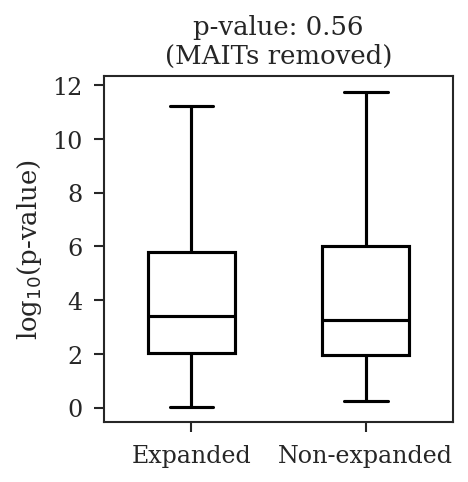

In [243]:
from clustcrdist.viz import simple_beeswarm

merged_res_without_mait = merged_res[merged_res.mapped_species_mait!='MAIT']

is_expanded = merged_res_without_mait[merged_res_without_mait.log2FC>3]
not_expanded = merged_res_without_mait[merged_res_without_mait.log2FC<=3]

fig, ax = plt.subplots(dpi=150, figsize=(3,3))

# Boxplot properties
capprops = {"color": "black", "linewidth": 1.5}
whiskerprops = {"color": "black", "linewidth": 1.5}
bprop = {"facecolor":"white","linewidth":1.5}
medprops = {"color":"black","linewidth":1.5}

ax.boxplot(
    [is_expanded.log10pval, not_expanded.log10pval], 
    widths=0.5, 
    showfliers=False,
    patch_artist=True, 
    vert=True, 
    boxprops=bprop, 
    medianprops=medprops, 
    capprops=capprops, 
    whiskerprops=whiskerprops,
    zorder=0
    )

ax.set_ylabel(r'log$_{10}$(p-value)')
ax.set_xticklabels(['Expanded','Non-expanded'])

S, p = mannwhitneyu(is_expanded.log10pval, not_expanded.log10pval)
ax.set_title(f'p-value: {p:.2f}\n(MAITs removed)')

In [614]:
merged_res[merged_res.evalue<.05][['evalue','pvalue']].max()

evalue    0.049391
pvalue    0.000005
dtype: float64

In [578]:
merged_res.columns

Index(['nSeqCDR3', 'avg.y', 'log2FC', 'timepoint', 'wi', 'wj', 'wij', 'wa',
       'wb', 'cdr3a_nucseq', 'cdr3b_nucseq', 'alpha_beta', 'method', 'r', 'ts',
       'pval', 'pval_adj', 'loss_a_frac', 'loss_b_frac', 'score', 'cdr3a',
       'va', 'ja', 'cdr3b', 'vb', 'jb', 'alpha_clone', 'beta_clone',
       'full_clone', 'pvalue', 'evalue', 'tcr_index', 'radius', 'num_nbrs',
       'expected_num_nbrs', 'bg_nbrs', 'cluster', 'mapped_species',
       'mapped_epitope', 'log10pval', 'mapped_species_mait',
       'annotation_color'],
      dtype='object')

## Integrating abundance info

In [21]:
longi = pd.read_table('./data/cd8_tp1_tp2_longitudinal_beta.tsv')
longi['nSeqCDR3'] = longi['nSeqCDR3'].str.lower()

longi_data = longi[['nSeqCDR3','avg.y','log2FC']].merge(acute, left_on='nSeqCDR3', right_on='cdr3b_nucseq')
commoncols = set(longi_data.columns).intersection(res_acute.data.columns)

merged_all = longi_data.merge(res_acute.data, on=list(commoncols), how='left')
merged_res = longi_data.merge(res_acute.data, on=list(commoncols), how='inner')
# merged_all['pvalue'] = merged_all.pvalue.fillna(1)

merged_all['log10pval'] = -np.log10(merged_all.pvalue)
merged_res['log10pval'] = -np.log10(merged_res.pvalue)

expanders = merged_all[merged_all.log2FC>3].reset_index(drop=True)

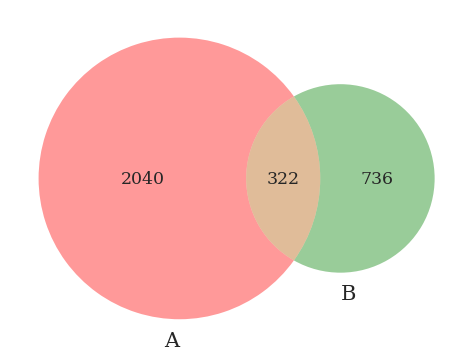

In [22]:
clonecols = ['cdr3b_nucseq','vb','jb','cdr3b','cdr3a_nucseq','va','ja','cdr3a']
expanders['full_clone'] = expanders[clonecols].astype(str).agg('_'.join, axis=1)
res_acute.data['full_clone'] = res_acute.data[clonecols].astype(str).agg('_'.join, axis=1)

from matplotlib_venn import venn2
ovl = (set(expanders.full_clone).intersection(set(res_acute.data.full_clone)))
venn2((set(expanders.full_clone), set(res_acute.data.full_clone)))

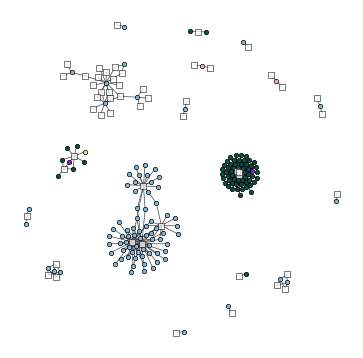

In [57]:
enriched_expanded = res_acute.data[res_acute.data.full_clone.isin(ovl)].reset_index()

fig, ax = plt.subplots()
nodes_enriched_expanded, edges_enriched_expanded, annot_enriched_expanded = vdjdb_annotation_network(enriched_expanded, vdjdb_paired, fig, ax)

node_to_species = {i:vdjdb_paired.loc[int(i.split('_')[0])]['antigen.species'] for i in nodes_enriched_expanded if 'VDJDB' in i}
node_to_epitope = {i:vdjdb_paired.loc[int(i.split('_')[0])]['antigen.epitope'] for i in nodes_enriched_expanded if 'VDJDB' in i}

sne_species = {}
for i in edges_enriched_expanded:
    tcr_index = int(i[0].split('_')[0])
    if tcr_index not in sne_species:
        sne_species[tcr_index] = {node_to_species[i[1]]}
    else:
        sne_species[tcr_index].add(node_to_species[i[1]])

sne_epitope = {}
for i in edges_enriched_expanded:
    tcr_index = int(i[0].split('_')[0])
    if tcr_index not in sne_epitope:
        sne_epitope[tcr_index] = {node_to_epitope[i[1]]}
    else:
        sne_epitope[tcr_index].add(node_to_epitope[i[1]])

mapped_species = [sne_species[x] if x in sne_species else None for x in enriched_expanded.index]
mapped_epitope = [sne_epitope[x] if x in sne_epitope else None for x in enriched_expanded.index]
enriched_expanded['mapped_species'] = mapped_species
enriched_expanded['mapped_epitope'] = mapped_epitope

In [64]:
nebv = enriched_expanded[enriched_expanded.evalue < .05].mapped_species.apply(lambda x: 'EBV' in x if x is not None else False).sum()
ncov = enriched_expanded[enriched_expanded.evalue < .05].mapped_species.apply(lambda x: 'SARS-CoV-2' in x if x is not None else False).sum()
ntot = enriched_expanded[enriched_expanded.evalue < .05].shape[0]

print(nebv / ntot, ncov / ntot)

0.05434782608695652 0.25


In [49]:
expanders

,nSeqCDR3,avg.y,log2FC,timepoint,wi,wj,wij,alpha_nuc,beta_nuc,wa,...,tcr_index,radius,num_nbrs,expected_num_nbrs,bg_nbrs,cluster,full_clone,mapped_species,mapped_epitope,log10pval
0,tgcaatagcgggggtgatacgcagtatttt,0.000019,4.326015,cd8_acute,5,14,16,TGTGCCGTGAACATGTATTCCGGGTATGCACTCAACTTC,TGCAATAGCGGGGGTGATACGCAGTATTTT,21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,tgcaatagcgggggtgatacgcagtatttt,0.000019,4.326015,cd8_acute,5,18,12,TGTGCTGTGGGACTAGGAAATAATGCAGGCAACATGCTCACCTTT,TGCAATAGCGGGGGTGATACGCAGTATTTT,17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,tgcagcaccggacagggcatgtatggctacaccttc,0.000072,6.199098,cd8_acute,3,18,21,TGCGGACCCCTCCAGGCTGGGAGTTACCAACTCACTTTC,TGCAGCACCGGACAGGGCATGTATGGCTACACCTTC,24,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,tgcagcaccggacagggcatgtatggctacaccttc,0.000072,6.199098,cd8_acute,7,19,20,TGTGCAGAGAGTACCCCGGGAGCACTTACTTTT,TGCAGCACCGGACAGGGCATGTATGGCTACACCTTC,27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,tgcagcatcagacaggcttctaactatggctacaccttc,0.000309,8.278093,cd8_acute,6,46,78,TGTGCTGTGAGAGACCTTTCAGATGGCCAGAAGCTGCTCTTT,TGCAGCATCAGACAGGCTTCTAACTATGGCTACACCTTC,84,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2338,tgtgctagtggtttgataggtcaaaacccaaatgagcagttcttc,0.000132,7.045112,cd8_acute,18,21,82,TGTGCTCGGATGGATAGCAGCTATAAATTGATCTTC,TGTGCTAGTGGTTTGATAGGTCAAAACCCAAATGAGCAGTTCTTC,100,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2339,tgtgctagtggtttggtactacagtccgcctacgagcagtacttc,0.000011,3.587683,cd8_acute,0,0,6,TGTGCTGTGACCAGAGAGCGGAGCACCCTCACCTTT,TGTGCTAGTGGTTTGGTACTACAGTCCGCCTACGAGCAGTACTTC,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2340,tgtgctagtggtttggtactacagtccgcctacgagcagtacttc,0.000011,3.587683,cd8_acute,0,0,6,TGCGCTGTGAAAGGCCAGGCAGGAACTGCTCTGATCTTT,TGTGCTAGTGGTTTGGTACTACAGTCCGCCTACGAGCAGTACTTC,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2341,tgtgctagtggtttggtgactagcgggagggcggacaccggggagc...,0.000385,8.593869,cd8_acute,2,19,159,TGTGCAGCAATAGAAACCTCCTACGACAAGGTGATATTT,TGTGCTAGTGGTTTGGTGACTAGCGGGAGGGCGGACACCGGGGAGC...,161,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


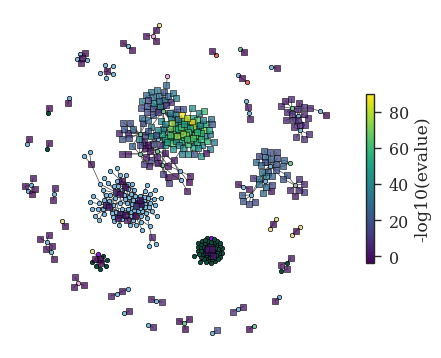

In [30]:
fig, ax = plt.subplots()
nodes_cd8_acute, edges_cd8_acute = vdjdb_annotation_network(res_acute.data, vdjdb_paired, fig, ax)

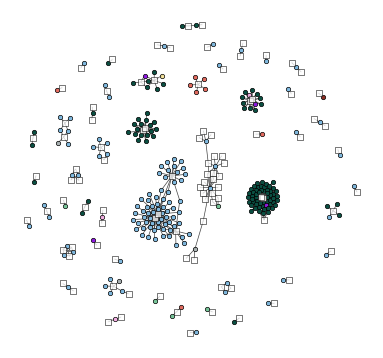

In [56]:
fig, ax = plt.subplots()
nodes_expanded, edges_expanded = vdjdb_annotation_network(expanders, vdjdb_paired, fig, ax)

Text(0, 0.5, 'log2FC')

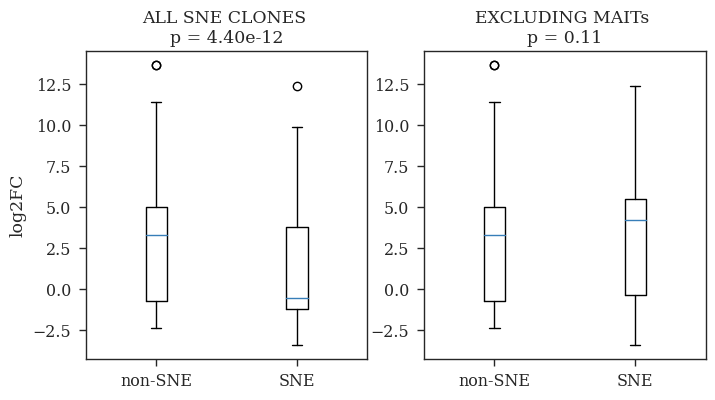

In [82]:
sne = merged_all[merged_all.evalue < .05]
nonsne = merged_all[merged_all.evalue >= .05]

fig, ax = plt.subplots(ncols=2, figsize=(8,4))

ax[0].boxplot(nonsne.log2FC, positions=[0])
ax[0].boxplot(sne.log2FC, positions=[1])

from scipy.stats import mannwhitneyu

S, p = mannwhitneyu(nonsne.log2FC, sne.log2FC)
ax[0].set_title(f'ALL SNE CLONES \np = {p:.2e}')

nonmait = sne[sne.va != 'TRAV1-2*01']
nonmait = nonmait[~nonmait.ja.isin(['TRAJ33*01','TRAJ12*01','TRAJ20*01'])]

ax[1].boxplot(nonsne.log2FC, positions=[0])
ax[1].boxplot(nonmait.log2FC, positions=[1])

S, p = mannwhitneyu(nonsne.log2FC, nonmait.log2FC)
ax[1].set_title(f'EXCLUDING MAITs \np = {p:.2f}')

ax[0].set_xticklabels(['non-SNE', 'SNE'])
ax[1].set_xticklabels(['non-SNE', 'SNE'])
ax[0].set_ylabel('log2FC')

In [180]:
node_to_species = {i:vdjdb_paired.loc[int(i.split('_')[0])]['antigen.species'] for i in nodes_expanded if 'VDJDB' in i}
node_to_epitope = {i:vdjdb_paired.loc[int(i.split('_')[0])]['antigen.epitope'] for i in nodes_expanded if 'VDJDB' in i}

sne_species = {}
for i in edges_expanded:
    tcr_index = int(i[0].split('_')[0])
    if tcr_index not in sne_species:
        sne_species[tcr_index] = {node_to_species[i[1]]}
    else:
        sne_species[tcr_index].add(node_to_species[i[1]])

sne_epitope = {}
for i in edges_expanded:
    tcr_index = int(i[0].split('_')[0])
    if tcr_index not in sne_epitope:
        sne_epitope[tcr_index] = {node_to_epitope[i[1]]}
    else:
        sne_epitope[tcr_index].add(node_to_epitope[i[1]])

mapped_species = [sne_species[x] if x in sne_species else None for x in expanders.index]
mapped_epitope = [sne_epitope[x] if x in sne_epitope else None for x in expanders.index]
expanders['mapped_species'] = mapped_species
expanders['mapped_epitope'] = mapped_epitope
expanders

,nSeqCDR3,avg.y,log2FC,timepoint,wi,wj,wij,alpha_nuc,beta_nuc,wa,...,radius,num_nbrs,expected_num_nbrs,bg_nbrs,cluster,log10pval,merged_clone,full_clone,mapped_species,mapped_epitope
0,tgcaatagcgggggtgatacgcagtatttt,0.000019,4.326015,cd8_acute,5,14,16,TGTGCCGTGAACATGTATTCCGGGTATGCACTCAACTTC,TGCAATAGCGGGGGTGATACGCAGTATTTT,21,...,NaN,NaN,NaN,NaN,NaN,NaN,tgcaatagcgggggtgatacgcagtatttt_TRBV20-1*01_TRB...,tgcaatagcgggggtgatacgcagtatttt_TRBV20-1*01_TRB...,None,None
1,tgcaatagcgggggtgatacgcagtatttt,0.000019,4.326015,cd8_acute,5,18,12,TGTGCTGTGGGACTAGGAAATAATGCAGGCAACATGCTCACCTTT,TGCAATAGCGGGGGTGATACGCAGTATTTT,17,...,NaN,NaN,NaN,NaN,NaN,NaN,tgcaatagcgggggtgatacgcagtatttt_TRBV20-1*01_TRB...,tgcaatagcgggggtgatacgcagtatttt_TRBV20-1*01_TRB...,None,None
2,tgcagcaccggacagggcatgtatggctacaccttc,0.000072,6.199098,cd8_acute,3,18,21,TGCGGACCCCTCCAGGCTGGGAGTTACCAACTCACTTTC,TGCAGCACCGGACAGGGCATGTATGGCTACACCTTC,24,...,NaN,NaN,NaN,NaN,NaN,NaN,tgcagcaccggacagggcatgtatggctacaccttc_TRBV29-1*...,tgcagcaccggacagggcatgtatggctacaccttc_TRBV29-1*...,None,None
3,tgcagcaccggacagggcatgtatggctacaccttc,0.000072,6.199098,cd8_acute,7,19,20,TGTGCAGAGAGTACCCCGGGAGCACTTACTTTT,TGCAGCACCGGACAGGGCATGTATGGCTACACCTTC,27,...,NaN,NaN,NaN,NaN,NaN,NaN,tgcagcaccggacagggcatgtatggctacaccttc_TRBV29-1*...,tgcagcaccggacagggcatgtatggctacaccttc_TRBV29-1*...,None,None
4,tgcagcatcagacaggcttctaactatggctacaccttc,0.000309,8.278093,cd8_acute,6,46,78,TGTGCTGTGAGAGACCTTTCAGATGGCCAGAAGCTGCTCTTT,TGCAGCATCAGACAGGCTTCTAACTATGGCTACACCTTC,84,...,NaN,NaN,NaN,NaN,NaN,NaN,tgcagcatcagacaggcttctaactatggctacaccttc_TRBV29...,tgcagcatcagacaggcttctaactatggctacaccttc_TRBV29...,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2357,tgtgctagtggtttgataggtcaaaacccaaatgagcagttcttc,0.000132,7.045112,cd8_acute,18,21,82,TGTGCTCGGATGGATAGCAGCTATAAATTGATCTTC,TGTGCTAGTGGTTTGATAGGTCAAAACCCAAATGAGCAGTTCTTC,100,...,NaN,NaN,NaN,NaN,NaN,NaN,tgtgctagtggtttgataggtcaaaacccaaatgagcagttcttc_...,tgtgctagtggtttgataggtcaaaacccaaatgagcagttcttc_...,None,None
2358,tgtgctagtggtttggtactacagtccgcctacgagcagtacttc,0.000011,3.587683,cd8_acute,0,0,6,TGTGCTGTGACCAGAGAGCGGAGCACCCTCACCTTT,TGTGCTAGTGGTTTGGTACTACAGTCCGCCTACGAGCAGTACTTC,6,...,NaN,NaN,NaN,NaN,NaN,NaN,tgtgctagtggtttggtactacagtccgcctacgagcagtacttc_...,tgtgctagtggtttggtactacagtccgcctacgagcagtacttc_...,None,None
2359,tgtgctagtggtttggtactacagtccgcctacgagcagtacttc,0.000011,3.587683,cd8_acute,0,0,6,TGCGCTGTGAAAGGCCAGGCAGGAACTGCTCTGATCTTT,TGTGCTAGTGGTTTGGTACTACAGTCCGCCTACGAGCAGTACTTC,6,...,NaN,NaN,NaN,NaN,NaN,NaN,tgtgctagtggtttggtactacagtccgcctacgagcagtacttc_...,tgtgctagtggtttggtactacagtccgcctacgagcagtacttc_...,None,None
2360,tgtgctagtggtttggtgactagcgggagggcggacaccggggagc...,0.000385,8.593869,cd8_acute,2,19,159,TGTGCAGCAATAGAAACCTCCTACGACAAGGTGATATTT,TGTGCTAGTGGTTTGGTGACTAGCGGGAGGGCGGACACCGGGGAGC...,161,...,NaN,NaN,NaN,NaN,NaN,NaN,tgtgctagtggtttggtgactagcgggagggcggacaccggggagc...,tgtgctagtggtttggtgactagcgggagggcggacaccggggagc...,None,None


In [141]:
sars = 0
ebv = 0
for i in expanders.mapped_species.dropna():
    if 'SARS-CoV-2' in i:
        sars += 1
    elif 'EBV' in i:
        ebv += 1
print(sars / expanders.shape[0], ebv / expanders.shape[0])

print(expanders.mapped_epitope.value_counts())

0.0275190516511431 0.008890770533446233
{SPRWYFYYL}                          44
{GLCTLVAML}                          11
{YLQPRTFLL}                           7
{CINGVCWTV, GLCTLVAML}                6
{LPRWYFYYL, SPRWYFYYL}                3
{LPRWYFYYL}                           2
{ELAGIGILTV}                          2
{RLPGVLPRA, CINGVCWTV, GLCTLVAML}     2
{SPRWYFYYL, NLVPMVATV}                2
{FLLNKEMYL}                           2
{SMQNCVLKL}                           2
{ALYGFVPVL}                           2
{GILGFVFTL}                           2
{NLVPMVATV}                           2
{TWLTYTGAI}                           1
{TPRVTGGGAM}                          1
{ALASCMGLI}                           1
{WLTNIFGTV}                           1
{KLSALGINAV}                          1
{GLCTLVAML, LLWNGPMAV, CINGVCWTV}     1
{FLYALALLL}                           1
{YLNTLTLAV, GLCTLVAML}                1
{LLLEWLAMA}                           1
{LPKGIMMNV}                           1


In [132]:
snesign = res_acute.data[res_acute.data.evalue<.05]
nonmait_sne = snesign[~(snesign.va == 'TRAV1-2*01')]

sars = 0
ebv = 0
for i in nonmait_sne.mapped_species.dropna():
    if 'SARS-CoV-2' in i:
        sars += 1
    elif 'EBV' in i:
        ebv += 1
print(sars / nonmait_sne.shape[0], ebv / nonmait_sne.shape[0])

0.1971153846153846 0.03365384615384615


In [138]:
ovl = set(nonmait_sne.full_clone).intersection(set(expanders.full_clone))
ovl = nonmait_sne[nonmait_sne.full_clone.isin(ovl)]

sars = 0
ebv = 0
for i in ovl.mapped_species.dropna():
    if 'SARS-CoV-2' in i:
        sars += 1
    elif 'EBV' in i:
        ebv += 1
print(sars / ovl.shape[0], ebv / ovl.shape[0])

0.2391304347826087 0.05434782608695652


In [150]:
df = pd.DataFrame([(0.0275190516511431, 0.1971153846153846, 0.1971153846153846, 'SARS-CoV-2'),
(0.008890770533446233, 0.03365384615384615, 0.05434782608695652, 'EBV')])

df.columns = ['all','nonmait','overlap','species']

df

,all,nonmait,overlap,species
0,0.027519,0.197115,0.197115,SARS-CoV-2
1,0.008891,0.033654,0.054348,EBV


In [47]:
expanded

NameError: name 'expanded' is not defined

/tmp/ipykernel_436488/1368392354.py:29: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[i].set_yticklabels(yticks, fontsize=15)
/tmp/ipykernel_436488/1368392354.py:29: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[i].set_yticklabels(yticks, fontsize=15)


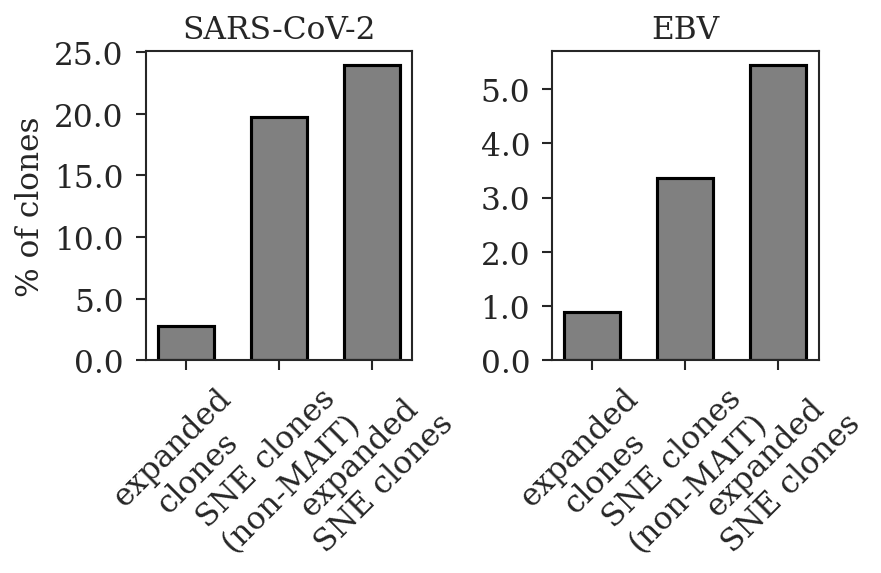

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data based on user's description
data = {
    'species': ['SARS-CoV-2', 'EBV'],
    'all': [0.027519, 0.008891],
    'nonmait': [0.197115, 0.033654],
    'overlap': [0.2391304347826087, 0.054348]
}

df = pd.DataFrame(data)

# Plot settings
fig, ax = plt.subplots(1, 2, figsize=(6,4), dpi=150, sharey=False)

# Plotting data for each species
species = df['species'].unique()
categories = ['all', 'nonmait', 'overlap']
x = np.arange(len(categories))  # Label locations
width = 0.6  # Bar width

for i, species_name in enumerate(species):
    values = df[df['species'] == species_name][categories].values[0]
    ax[i].bar(x, values*100, width, color='grey', edgecolor='black', linewidth=1.5)
    ax[i].set_title(species_name, fontsize=15)
    ax[i].set_xticks(x)
    yticks = ax[i].get_yticks()
    ax[i].set_yticklabels(yticks, fontsize=15)
    ax[i].set_xticklabels(categories)

ax[0].set_ylabel(r'% of clones', fontsize=15)
ax[0].set_xticklabels(['expanded\nclones','SNE clones\n(non-MAIT)', 'expanded\nSNE clones'], rotation=45, fontsize=15)
ax[1].set_xticklabels(['expanded\nclones','SNE clones\n(non-MAIT)', 'expanded\nSNE clones'], rotation=45, fontsize=15)
    # ax[i].set_ylim(0, max(df[categories].values.flatten()) * 1.2)

# Displaying the plot
plt.tight_layout()
plt.show()
# fig.savefig('../sne_manuscript/manuscript_figures/tirtl_expanded_sne_sars_ebv.svg', bbox_inches='tight')


In [24]:
final = longi_data.merge(res_acute.data, on=list(commoncols), how='inner')

sars_spec = final[final.mapped_species.apply(lambda x: 'SARS-CoV-2' in x if x is not None else False)]
sars_spec[sars_spec.cluster == 1].cdr3b

AttributeError: 'DataFrame' object has no attribute 'mapped_species'

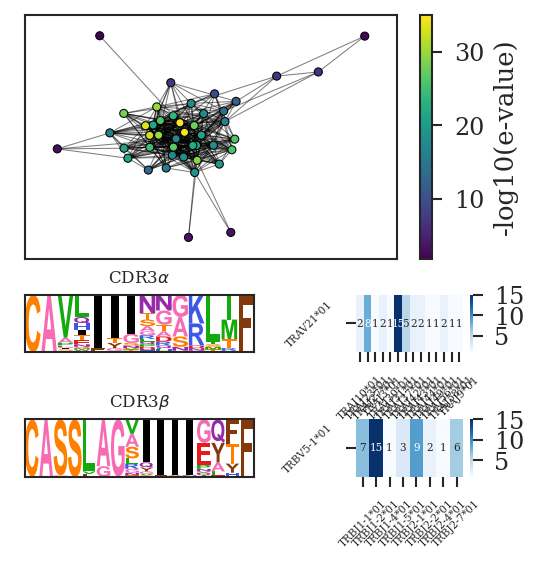

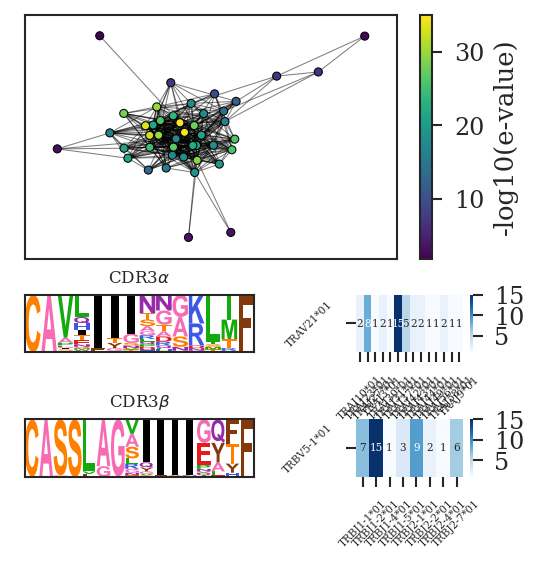

In [173]:
res_acute.draw_cluster(1)

Some extra random code for TCR specificity annotation through IMW DETECT

In [277]:
def paired_to_long(df):

    # Step 1: Rename columns for consistency
    df.rename(columns={'va': 'v_call_alpha', 'cdr3a': 'junction_aa_alpha', 'ja': 'j_call_alpha',
                    'vb': 'v_call_beta', 'cdr3b': 'junction_aa_beta', 'jb': 'j_call_beta'}, inplace=True)

    # Step 2: Create separate DataFrames for alpha and beta, with cell_id linking pairs
    alpha_df = df[['v_call_alpha', 'junction_aa_alpha', 'j_call_alpha']].copy()
    alpha_df.columns = ['v_call', 'junction_aa', 'j_call']
    alpha_df['chain'] = 'alpha'
    alpha_df['cell_id'] = alpha_df.index

    beta_df = df[['v_call_beta', 'junction_aa_beta', 'j_call_beta']].copy()
    beta_df.columns = ['v_call', 'junction_aa', 'j_call']
    beta_df['chain'] = 'beta'
    beta_df['cell_id'] = beta_df.index

    # Step 3: Concatenate alpha and beta DataFrames
    return pd.concat([alpha_df, beta_df]).sort_values('cell_id').reset_index(drop=True)

def long_to_paired(long_df):
    # Separate alpha and beta chains based on the 'chain' column
    alpha_df = long_df[long_df['chain'] == 'alpha'].copy()
    beta_df = long_df[long_df['chain'] == 'beta'].copy()
    
    # Ensure both DataFrames have the same cell_id count before merging
    if len(alpha_df) != len(beta_df):
        raise ValueError("Mismatch between alpha and beta chains. Cannot convert to paired format.")
    
    # Drop the 'chain' column and rename columns for alpha and beta chains
    alpha_df = alpha_df.rename(columns={'v_call': 'va', 'junction_aa': 'cdr3a', 'j_call': 'ja'}).drop(columns='chain')
    beta_df = beta_df.rename(columns={'v_call': 'vb', 'junction_aa': 'cdr3b', 'j_call': 'jb'}).drop(columns='chain')
    
    # Identify other common columns (apart from 'cell_id') to merge without suffixes
    imw_columns = ['Epitope', 'Score', 'Antigen', 'Species', 'HLA']
    
    # Merge alpha and beta DataFrames based on 'cell_id', keeping only one of each common column
    paired_df = pd.merge(alpha_df, beta_df, on=['cell_id'] + list(imw_columns), how='inner')

    # Combine the 'Reference TCRs' columns from alpha and beta chains
    paired_df['Reference TCRs'] = paired_df.apply(
        lambda row: (row['Reference TCRs_x'] or []) + (row['Reference TCRs_y'] or []), axis=1
    )
    
    # Drop the 'cell_id' column as it is no longer needed in paired format
    paired_df = paired_df.drop(columns=['Reference TCRs_x', 'Reference TCRs_y', 'cell_id'])
    
    return paired_df


def run_imw_detect(data, outname_base='/home/sebastiaan/phd/repositories/immune_response_detection/data/imw_out'):
    # Convert data to long format
    long = paired_to_long(data)
    
    # Determine the number of chunks needed (max 10,000 rows per chunk)
    chunk_size = 10000
    num_chunks = (len(long) + chunk_size - 1) // chunk_size  # Ceiling division
    
    # Placeholder for results
    results = []
    
    for i in range(num_chunks):
        # Split data into chunks
        chunk = long.iloc[i * chunk_size : (i + 1) * chunk_size]
        
        # Save chunk to temporary file
        imw_filename = f'/home/sebastiaan/phd/repositories/immune_response_detection/data/imw_data_chunk_{i}.tsv'
        chunk.to_csv(imw_filename, sep='\t', index=False)
        
        # Define output file name for this chunk
        outname = f"{outname_base}_chunk_{i}.tsv"
        
        # Run the command line software on each chunk
        os.system(f'~/imw_detect -i {imw_filename} -o {outname} -d imwdb -l f86ab52c-76ba-520e-93a8-2843f3f0e889')
        
        # Read the output and store in results list
        imw_chunk = pd.read_table(outname)
        results.append(imw_chunk)
        
        # Remove temporary files
        os.remove(imw_filename)
        os.remove(outname)
    
    # Concatenate all chunks into a single DataFrame
    imw = pd.concat(results, ignore_index=True)
    return imw

In [ ]:
imw = run_imw_detect(res_pre.data)
imw_sign = imw[imw.Score > 0.23]
long_to_paired(imw_sign)

## Old

In [ ]:
import matplotlib.pyplot as plt
import igraph as ig

import seaborn as sns

# Setting up the plot styles
plt.style.use(['seaborn-v0_8-white', 'seaborn-v0_8-paper'])

# Ensure font configuration is applied
plt.rc('font', family='serif')  # This should work, but let's ensure it's consistent
plt.rcParams['font.family'] = 'serif'  # This makes sure Matplotlib uses serif fonts

# Optional: Update Seaborn's style context if needed
sns.set_palette('Set1')
sns.set_context('paper', font_scale=1.3)    # for single-column figure

# Alternatively, configure font within Seaborn
sns.set(font='serif')

# fig, ax = plt.subplots(dpi=150, figsize=(12,4), ncols=3)

def annotate_network(res, persistent, ax, size=True):

        layout = res.Gi.layout("graphopt", niter=1000)

        node_data = res.data.iloc[[i['_nx_name'] for i in res.Gi.vs]]
        node_data['color'] = node_data.full_clone.apply(lambda x: 'tab:red' if x in persistent else 'tab:grey')

        x = [i[0] for i in layout]
        y = [i[1] for i in layout]

        visual_style = {'edge_width': 0.5,}
        ig.plot(res.Gi,
                layout=layout,
                **visual_style,
                target=ax)

        c = node_data['color']
        if size:
                s = -np.log10(node_data.evalue) * 2
        else:
                s = 15
        ax.scatter(x, y, c=c, cmap='viridis', s=s, edgecolors='black', linewidths=0.5)

fig, ax = plt.subplots(dpi=150, figsize=(12,4), ncols=3)

persistent = set(sign_pre.full_clone).intersection(set(sign_acute.full_clone)).intersection(set(sign_conv.full_clone))

annotate_network(res_pre, persistent, ax[0], size=False)
annotate_network(res_acute, persistent, ax[1], size=False)
annotate_network(res_conv, persistent, ax[2], size=False)

ax[0].set_title('Pre')
ax[1].set_title('Acute')
ax[2].set_title('Convalescent')

import matplotlib.lines as mlines

# Create custom legend entries
persistent_marker = mlines.Line2D([], [], color='tab:red', marker='o', markersize=10, markeredgewidth=1.5, markeredgecolor='black', linestyle='None')
private_sne_marker = mlines.Line2D([], [], color='tab:grey', marker='o', markersize=10, markeredgewidth=1.5, markeredgecolor='black', linestyle='None')

# Add the legend to the figure
fig.legend([persistent_marker, private_sne_marker], ['Persistent SNE clone', 'Private SNE clone'],
           loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2, frameon=False)